<a href="https://colab.research.google.com/github/Matifi1310/portfolio/blob/Parte-2/examen.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Uso de la api de Banco Mundial


La versión `1.0.12` del Paquete wbgapi de Python Ya está disponible. Este paquete lleva casi un año en el Índice de Paquetes de Python y la última versión incorpora varias nuevas funciones para la exploración y la búsqueda en bases de datos sean sencillas e interactivas.



In [26]:
# Instalar biblioteca
%pip install wbgapi

In [27]:
# Importar bibiotecas
import wbgapi as wb
from google.colab import drive
from datetime import datetime
import pandas as pd
drive.mount('/content/drive')

import sys
sys.path.append('/content/drive/MyDrive/UDP-CcsDatos2025-2')

import my_func as fn

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Usando la api del Banco Mundial es posible acceder a estadísticas diversas sobre desarrollo económico. A continuación extraeremos información de 65 indicadores económicos

In [28]:
# Indicadores a consultar
dicc_indicadores_wb = {
    "NY.GDP.MKTP.PP.KD": "GDP, PPP (constant 2021 international $)",
    "SP.POP.GROW": "Population growth (annual %)",
    "SP.POP.TOTL": "Population, total",
    "SP.POP.TOTL.FE.IN": "Population, female",
    "SP.POP.TOTL.FE.ZS": "Population, female (% of total population)",
    "SP.POP.TOTL.MA.IN": "Population, male",
    "SP.POP.TOTL.MA.ZS": "Population, male (% of total population)",
    "SP.URB.GROW": "Urban population growth (annual %)",
    "SP.URB.TOTL": "Urban population",
    "SP.URB.TOTL.IN.ZS": "Urban population (% of total population)",
    "SP.RUR.TOTL": "Rural population",
    "SP.RUR.TOTL.ZG": "Rural population growth (annual %)",
    "SP.RUR.TOTL.ZS": "Rural population (% of total population)",
    "SL.TLF.TOTL.IN": "Labor force, total",
    "SL.TLF.TOTL.FE.ZS": "Labor force, female (% of total labor force)",
    "SL.UEM.TOTL.FE.NE.ZS": "Unemployment, female (% of female labor force) (national estimate)",
    "SL.UEM.TOTL.FE.ZS": "Unemployment, female (% of female labor force) (modeled ILO estimate)",
    "SL.UEM.TOTL.MA.NE.ZS": "Unemployment, male (% of male labor force) (national estimate)",
    "SL.UEM.TOTL.MA.ZS": "Unemployment, male (% of male labor force) (modeled ILO estimate)",
    "SL.UEM.TOTL.NE.ZS": "Unemployment, total (% of total labor force) (national estimate)",
    "SL.UEM.TOTL.ZS": "Unemployment, total (% of total labor force) (modeled ILO estimate)",
    "FP.CPI.TOTL.ZG": "Inflation, consumer prices (annual %)",
    "GC.TAX.EXPT.CN": "Taxes on exports (current LCU)",
    "GC.TAX.EXPT.ZS": "Taxes on exports (% of tax revenue)",
    "NE.EXP.GNFS.KD.ZG": "Exports of goods and services (annual % growth)",
    "NE.EXP.GNFS.KN": "Exports of goods and services (constant LCU)",
    "NE.EXP.GNFS.ZS": "Exports of goods and services (% of GDP)",
    "NV.AGR.TOTL.CD": "Agriculture, forestry, and fishing, value added (current US$)",
    "NV.AGR.TOTL.CN": "Agriculture, forestry, and fishing, value added (current LCU)",
    "NV.IND.MANF.CD": "Manufacturing, value added (current US$)",
    "NV.IND.MANF.CN": "Manufacturing, value added (current LCU)",
    "NV.IND.TOTL.CD": "Industry (including construction), value added (current US$)",
    "NV.IND.TOTL.CN": "Industry (including construction), value added (current LCU)",
    "NV.SRV.TOTL.CD": "Services, value added (current US$)",
    "NV.SRV.TOTL.CN": "Services, value added (current LCU)",
    "GE.EST": "Government Effectiveness: Estimate",
    "NE.CON.GOVT.KN": "General government final consumption expenditure (constant LCU)",
    "NE.CON.GOVT.ZS": "General government final consumption expenditure (% of GDP)",
    "NE.CON.PRVT.CD": "Households and NPISHs Final consumption expenditure (current US$)",
    "NE.CON.PRVT.CN": "Households and NPISHs Final consumption expenditure (current LCU)",
    "GC.DOD.TOTL.CN": "Central government debt, total (current LCU)",
    "GC.DOD.TOTL.GD.ZS": "Central government debt, total (% of GDP)",
    "BM.KLT.DINV.CD.WD": "Foreign direct investment, net outflows (BoP, current US$)",
    "BX.KLT.DINV.WD.GD.ZS": "Foreign direct investment, net inflows (% of GDP)",
    "EG.ELC.LOSS.ZS": "Electric power transmission and distribution losses (% of output)",
    "EG.USE.ELEC.KH.PC": "Electric power consumption (kWh per capita)",
    "EN.GHG.CO2.IP.MT.CE.AR5": "Carbon dioxide emissions from Industrial Processes (Mt CO2e)",
    "SE.PRM.NENR": "School enrollment, primary (% net)",
    "SE.PRM.NENR.FE": "School enrollment, primary, female (% net)",
    "SE.PRM.NENR.MA": "School enrollment, primary, male (% net)",
    "SE.SEC.ENRR": "School enrollment, secondary (% gross)",
    "SE.SEC.ENRR.FE": "School enrollment, secondary, female (% gross)",
    "SE.SEC.ENRR.MA": "School enrollment, secondary, male (% gross)",
    "SE.TER.ENRR": "School enrollment, tertiary (% gross)",
    "SE.TER.ENRR.FE": "School enrollment, tertiary, female (% gross)",
    "SE.TER.ENRR.MA": "School enrollment, tertiary, male (% gross)",
    "SP.DYN.LE00.IN": "Life expectancy at birth, total (years)",
    "SP.DYN.LE00.FE.IN": "Life expectancy at birth, female (years)",
    "SP.DYN.LE00.MA.IN": "Life expectancy at birth, male (years)",
    "EG.CFT.ACCS.ZS": "Access to clean fuels and technologies for cooking (% of population)",
    "EG.CFT.ACCS.RU.ZS": "Access to clean fuels and technologies for cooking, rural (% of rural population)",
    "EG.CFT.ACCS.UR.ZS": "Access to clean fuels and technologies for cooking, urban (% of urban population)",
    "IT.NET.USER.FE.ZS": "Individuals using the Internet, female (% of female population)",
    "IT.NET.USER.MA.ZS": "Individuals using the Internet, male (% of male population)",
    "IT.NET.USER.ZS": "Individuals using the Internet (% of population)",
}


In [29]:
# Descarga de datos
paises_wb_raw = fn.descargar_en_chunks(indicadores=dicc_indicadores_wb, años = 2023, chunk_size=15)

Descargando bloque 1: ['NY.GDP.MKTP.PP.KD', 'SP.POP.GROW', 'SP.POP.TOTL', 'SP.POP.TOTL.FE.IN', 'SP.POP.TOTL.FE.ZS', 'SP.POP.TOTL.MA.IN', 'SP.POP.TOTL.MA.ZS', 'SP.URB.GROW', 'SP.URB.TOTL', 'SP.URB.TOTL.IN.ZS', 'SP.RUR.TOTL', 'SP.RUR.TOTL.ZG', 'SP.RUR.TOTL.ZS', 'SL.TLF.TOTL.IN', 'SL.TLF.TOTL.FE.ZS']
Descargando bloque 2: ['SL.UEM.TOTL.FE.NE.ZS', 'SL.UEM.TOTL.FE.ZS', 'SL.UEM.TOTL.MA.NE.ZS', 'SL.UEM.TOTL.MA.ZS', 'SL.UEM.TOTL.NE.ZS', 'SL.UEM.TOTL.ZS', 'FP.CPI.TOTL.ZG', 'GC.TAX.EXPT.CN', 'GC.TAX.EXPT.ZS', 'NE.EXP.GNFS.KD.ZG', 'NE.EXP.GNFS.KN', 'NE.EXP.GNFS.ZS', 'NV.AGR.TOTL.CD', 'NV.AGR.TOTL.CN', 'NV.IND.MANF.CD']
Descargando bloque 3: ['NV.IND.MANF.CN', 'NV.IND.TOTL.CD', 'NV.IND.TOTL.CN', 'NV.SRV.TOTL.CD', 'NV.SRV.TOTL.CN', 'GE.EST', 'NE.CON.GOVT.KN', 'NE.CON.GOVT.ZS', 'NE.CON.PRVT.CD', 'NE.CON.PRVT.CN', 'GC.DOD.TOTL.CN', 'GC.DOD.TOTL.GD.ZS', 'BM.KLT.DINV.CD.WD', 'BX.KLT.DINV.WD.GD.ZS', 'EG.ELC.LOSS.ZS']
Descargando bloque 4: ['EG.USE.ELEC.KH.PC', 'EN.GHG.CO2.IP.MT.CE.AR5', 'SE.PRM.NENR', '

In [30]:
# Seleccionar solamente paises usando código ISO
table_dict = vars(wb.economy.info())
df_paises = pd.DataFrame(table_dict.get('items'))
iso_list = list(df_paises[df_paises['aggregate'] == False]['id'])

## Análisis exploratorio de datos

In [31]:
paises_wb_raw.tail(5)

,country,Country,NY.GDP.MKTP.PP.KD,SL.TLF.TOTL.FE.ZS,SL.TLF.TOTL.IN,SP.POP.GROW,SP.POP.TOTL,SP.POP.TOTL.FE.IN,SP.POP.TOTL.FE.ZS,SP.POP.TOTL.MA.IN,...,SE.TER.ENRR.FE,SE.TER.ENRR.MA,SP.DYN.LE00.FE.IN,SP.DYN.LE00.IN,SP.DYN.LE00.MA.IN,EG.CFT.ACCS.RU.ZS,EG.CFT.ACCS.UR.ZS,IT.NET.USER.FE.ZS,IT.NET.USER.MA.ZS,IT.NET.USER.ZS
261,CEB,Central Europe and the Baltics,4.218704e+12,45.670155,49100893.0,0.111693,100183707.0,51639515.0,51.544825,48544192.0,...,80.939987,56.712559,81.624607,77.896625,74.354109,100.000000,100.000000,NaN,NaN,NaN
262,CSS,Caribbean small states,1.338577e+11,43.965332,1919128.0,0.501131,4519904.0,2293907.0,50.751230,2225997.0,...,NaN,NaN,76.456921,73.171645,69.986624,95.267180,98.879872,NaN,NaN,NaN
263,ARB,Arab World,8.097600e+12,19.141318,132483437.0,2.255866,482105978.0,232702770.0,48.267971,249403208.0,...,34.757931,31.807100,74.418910,72.444678,70.619437,77.839625,93.857501,NaN,NaN,NaN
264,AFW,Africa Western and Central,2.992692e+12,46.355771,212022202.0,2.386204,509398589.0,252899429.0,49.646669,256499160.0,...,NaN,NaN,59.997102,58.855722,57.752356,6.004144,45.206379,33.0,44.0,38.5
265,AFE,Africa Eastern and Southern,3.065002e+12,47.278292,288476515.0,2.519167,750491370.0,379019549.0,50.502852,371471821.0,...,NaN,NaN,67.914632,65.146154,62.395419,10.288154,41.289974,24.8,30.9,27.8


Al revisar los primeros y últimos registros se observa que la extracción de datos contiene datos de paises y de áreas geográficas. Por lo tanto se procede a la limpieza de datos

In [32]:
# Seleccionar solamente paises usando código ISO
table_dict = vars(wb.economy.info())
df_paises = pd.DataFrame(table_dict.get('items'))
iso_list = list(df_paises[df_paises['aggregate'] == False]['id'])

In [33]:
#Seleccionar solamente paises.
paises_wb_raw = paises_wb_raw[paises_wb_raw['country'].isin(iso_list)].reset_index(drop = True)

Una vez seleccionado solamente los paises procederemos al análisis exploratorio de los datos.

In [34]:
paises_wb_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198 entries, 0 to 197
Data columns (total 67 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   country                  198 non-null    object 
 1   Country                  198 non-null    object 
 2   NY.GDP.MKTP.PP.KD        198 non-null    float64
 3   SL.TLF.TOTL.FE.ZS        173 non-null    float64
 4   SL.TLF.TOTL.IN           173 non-null    float64
 5   SP.POP.GROW              198 non-null    float64
 6   SP.POP.TOTL              198 non-null    float64
 7   SP.POP.TOTL.FE.IN        198 non-null    float64
 8   SP.POP.TOTL.FE.ZS        198 non-null    float64
 9   SP.POP.TOTL.MA.IN        198 non-null    float64
 10  SP.POP.TOTL.MA.ZS        198 non-null    float64
 11  SP.RUR.TOTL              198 non-null    float64
 12  SP.RUR.TOTL.ZG           189 non-null    float64
 13  SP.RUR.TOTL.ZS           198 non-null    float64
 14  SP.URB.GROW              1

Existen variables con un alto volumnen de datos faltantes. Usaremos la siguiente regla para el tratamiento de los mismos:
- Si `NaN` > 15% Se procede a eliminar la variable.
- Si `NaN` < 15% Se procede a imputar datos.

In [35]:
# Condición booleana
mask_bool = paises_wb_raw.isna().mean()>0.15
# Selección columnas nulas
drop_columns = list(paises_wb_raw.isna().mean()[mask_bool].index)
# Eliminar columnas con muchos nulos
paises_wb = paises_wb_raw.drop(columns = drop_columns)

A continuación revisaremos la cantidad de datos de nuestro DataFrame

In [36]:
print(f'El dataFrame contiene {paises_wb.shape[0]} filas y {paises_wb.shape[1]} columnas, de las cuales {len(paises_wb.isna().mean()[paises_wb.isna().mean()>0].index)} contienen registros nulos bajo el 15%')

El dataFrame contiene 198 filas y 41 columnas, de las cuales 24 contienen registros nulos bajo el 15%


## Imputación de datos

Se realizará a modo de prueba una imputación paramétrica a fin de aplicar algoritmo de reducción de dimensionalidad

In [37]:
# Guardar como indice la columna Country
paises_wb.index = paises_wb['Country']

In [38]:
# Eliminar columnas de texto
paises_wb = paises_wb.drop(columns = ['country','Country'])

In [39]:
from sklearn.impute import SimpleImputer
import numpy as np
simple = SimpleImputer(missing_values=np.nan, strategy='mean')
imputer = simple.fit_transform(paises_wb)
paises_wb = pd.DataFrame(imputer, columns = paises_wb.columns)

In [40]:
print(f'El dataFrame contiene {paises_wb.shape[0]} filas y {paises_wb.shape[1]} columnas, de las cuales {len(paises_wb.isna().mean()[paises_wb.isna().mean()>0].index)} contienen registros.')

El dataFrame contiene 198 filas y 39 columnas, de las cuales 0 contienen registros.


In [41]:
paises_wb.head()

,NY.GDP.MKTP.PP.KD,SL.TLF.TOTL.FE.ZS,SL.TLF.TOTL.IN,SP.POP.GROW,SP.POP.TOTL,SP.POP.TOTL.FE.IN,SP.POP.TOTL.FE.ZS,SP.POP.TOTL.MA.IN,SP.POP.TOTL.MA.ZS,SP.RUR.TOTL,...,NV.SRV.TOTL.CD,NV.SRV.TOTL.CN,EG.CFT.ACCS.ZS,EN.GHG.CO2.IP.MT.CE.AR5,SP.DYN.LE00.FE.IN,SP.DYN.LE00.IN,SP.DYN.LE00.MA.IN,EG.CFT.ACCS.RU.ZS,EG.CFT.ACCS.UR.ZS,IT.NET.USER.ZS
0,8.526678e+10,49.843240,6.232464e+06,1.677096,16340822.0,8559888.0,52.383460,7780934.0,47.616540,9920197.0,...,1.777929e+10,3.348446e+10,30.700000,0.963600,65.013,62.775,60.226,7.500000,77.000000,38.4266
1,7.612916e+10,46.170619,7.147630e+06,2.794068,20723965.0,10467717.0,50.510204,10256248.0,49.489796,11392257.0,...,1.566890e+10,3.167001e+11,9.200000,1.290500,68.673,66.349,63.936,2.300000,16.800000,33.0000
2,2.769440e+10,41.898361,2.076029e+07,2.393265,5165775.0,2598445.0,50.301172,2567330.0,49.698828,678902.0,...,1.044720e+10,1.044720e+10,70.320055,16.892307,71.502,65.170,59.691,62.271154,78.501099,86.6377
3,1.359364e+12,48.623244,5.679900e+07,0.671429,100352192.0,51201223.0,51.021529,49150969.0,48.978471,62088011.0,...,1.834968e+11,4.364896e+15,98.700000,50.189800,79.264,74.588,69.877,98.700000,99.400000,78.0800
4,1.030020e+09,46.126995,1.154530e+05,2.324816,320409.0,158611.0,49.502667,161798.0,50.497333,249069.0,...,2.404534e+11,5.135587e+14,20.600000,0.001100,73.927,71.477,69.445,9.000000,52.300000,45.7313


In [42]:
y = paises_wb['NY.GDP.MKTP.PP.KD']
X = paises_wb.drop(columns='NY.GDP.MKTP.PP.KD')

Vemos los Outliers con ABOD

In [43]:
%pip install pyod

In [65]:
df_out['ABOD_outlier'].sum()

np.int64(2)

Tabla de estadistica descriptiva

In [66]:
paises_wb.describe()

,NY.GDP.MKTP.PP.KD,SL.TLF.TOTL.FE.ZS,SL.TLF.TOTL.IN,SP.POP.GROW,SP.POP.TOTL,SP.POP.TOTL.FE.IN,SP.POP.TOTL.FE.ZS,SP.POP.TOTL.MA.IN,SP.POP.TOTL.MA.ZS,SP.RUR.TOTL,...,NV.SRV.TOTL.CD,NV.SRV.TOTL.CN,EG.CFT.ACCS.ZS,EN.GHG.CO2.IP.MT.CE.AR5,SP.DYN.LE00.FE.IN,SP.DYN.LE00.IN,SP.DYN.LE00.MA.IN,EG.CFT.ACCS.RU.ZS,EG.CFT.ACCS.UR.ZS,IT.NET.USER.ZS
count,1.980000e+02,198.000000,1.980000e+02,198.000000,1.980000e+02,1.980000e+02,198.000000,1.980000e+02,198.000000,1.980000e+02,...,1.980000e+02,1.980000e+02,198.000000,198.000000,198.000000,198.000000,198.000000,198.000000,198.000000,198.000000
mean,8.388712e+11,41.898361,2.076029e+07,1.152752,3.999611e+07,1.987776e+07,49.973491,2.011836e+07,50.026509,1.709937e+07,...,2.404534e+11,5.135587e+14,70.320055,16.892307,76.119303,73.476060,70.910354,62.271154,78.501099,72.290555
std,3.129922e+12,8.426943,7.136206e+07,1.576210,1.484957e+08,7.252840e+07,2.993389,7.598056e+07,2.993389,7.663858e+07,...,8.451771e+11,5.513127e+15,34.965656,105.827154,7.221813,7.085527,7.104323,39.610836,31.051599,22.896828
min,5.705451e+07,6.846247,3.361400e+04,-8.423008,9.816000e+03,4.795000e+03,28.483741,5.021000e+03,45.079120,0.000000e+00,...,1.838905e+08,1.838905e+08,0.100000,0.000000,54.743000,54.462000,53.195000,0.000000,0.100000,11.078400
25%,2.586691e+10,40.970220,1.602226e+06,0.282878,1.373786e+06,6.876850e+05,49.651875,6.826450e+05,48.810555,4.134135e+05,...,6.217830e+09,4.676045e+10,46.875000,0.162450,70.733000,67.713000,65.379000,17.725000,72.600000,60.903000
50%,8.596764e+10,43.286283,5.473392e+06,1.112108,7.335048e+06,3.672054e+06,50.329281,3.560820e+06,49.670719,1.983892e+06,...,2.566337e+10,6.449825e+11,88.300000,1.623700,77.486500,74.292890,70.666000,75.750000,95.800000,78.872150
75%,4.615291e+11,47.358224,2.076029e+07,2.088224,2.936413e+07,1.403224e+07,51.189445,1.424457e+07,50.348125,1.024225e+07,...,2.056168e+11,1.017999e+13,100.000000,9.128250,81.700000,78.485976,75.803000,100.000000,100.000000,89.197700
max,3.200488e+13,54.670843,7.746076e+08,6.527050,1.438070e+09,6.961863e+08,54.920880,7.418833e+08,71.516259,9.337718e+08,...,1.029315e+13,7.703243e+16,100.000000,1456.092000,88.090000,85.706000,84.206000,100.000000,100.000000,100.000000


Mostrar la distribución del PIB

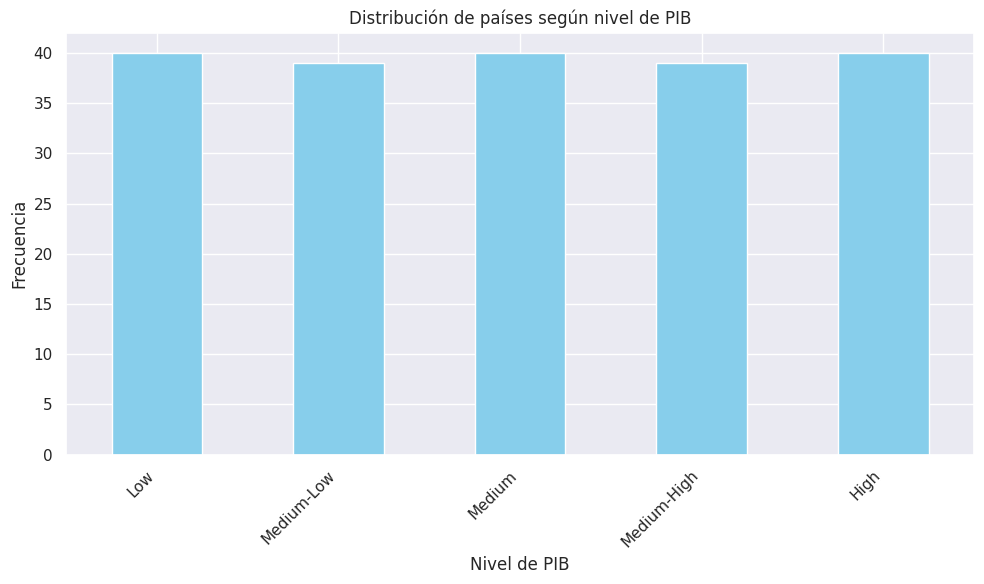

In [67]:
import matplotlib.pyplot as plt
import pandas as pd

# Definir los umbrales para las categorías de PIB
# Usaremos percentiles para definir los umbrales de manera relativa a la distribución actual

percentiles = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
bins = paises_wb['NY.GDP.MKTP.PP.KD'].quantile(percentiles).tolist()

orden = ['Low', 'Medium-Low', 'Medium', 'Medium-High', 'High']

# Si hay menos bins que categorías deseadas (por ejemplo, si muchos valores son iguales),
# ajustamos el número de categorías para que coincida con el número de bins - 1
if len(bins) - 1 < len(orden):
    orden = orden[:len(bins)-1]

# Crear la columna categórica 'Nivel_PIB'
paises_wb['Nivel_PIB'] = pd.cut(
    paises_wb['NY.GDP.MKTP.PP.KD'],
    bins=bins,
    labels=orden,
    include_lowest=True,
    right=True
)

# Generar el gráfico de barras
plt.figure(figsize=(10, 6))
paises_wb['Nivel_PIB'].value_counts().reindex(orden).plot(kind='bar', color='skyblue')
plt.xlabel('Nivel de PIB')
plt.ylabel('Frecuencia')
plt.title('Distribución de países según nivel de PIB')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Mapa con la distribución del PIB

In [25]:
import plotly.express as px
import pandas as pd

#df temporal para el mapa
df_for_map = paises_wb.copy()

#usamos el ISO_Code y CountryName
df_for_map['ISO_Code'] = paises_wb_raw['country']
df_for_map['CountryName'] = paises_wb_raw['Country']

# mapa de colores
color_map = {
    'Low': 'lightgreen',
    'Medium-Low': 'yellow',
    'Medium': 'orange',
    'Medium-High': 'red',
    'High': 'darkred'
}
#mapa
fig = px.choropleth(
    df_for_map,
    locations='ISO_Code',
    locationmode='ISO-3',
    color='Nivel_PIB',
    hover_name='CountryName',
    color_discrete_map=color_map,
    category_orders={'Nivel_PIB': ['Low', 'Medium-Low', 'Medium', 'Medium-High', 'High']},
    projection='natural earth',
    title='Distribución Global del PIB por Nivel'
)

fig.update_layout(width=1000, height=600, title_font_size=24)
fig.show()

## ETAPA 2:Reducción de Dimensionalidad con PCA



In [45]:
# Importar biliotecas
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import statsmodels.api as sm
from scipy.stats import chi2

In [46]:
df = paises_wb.select_dtypes(include=['int64', 'float64'])

Vamos a imputar meiante Random Forest y Media

In [47]:
# Escalar datos
scaler = StandardScaler()
data_std = scaler.fit_transform(df)
df_std = pd.DataFrame(df, columns=df.columns)

PCA mediante SKLearn

In [48]:
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

Imputar por media

In [49]:

# re-inicializar 'df' correctamente
df = paises_wb.select_dtypes(include=['int64', 'float64']).copy()

imputer = SimpleImputer(strategy='mean')
paises = pd.DataFrame(imputer.fit_transform(df), columns=df.columns, index=df.index)

In [50]:
paises.head()

,NY.GDP.MKTP.PP.KD,SL.TLF.TOTL.FE.ZS,SL.TLF.TOTL.IN,SP.POP.GROW,SP.POP.TOTL,SP.POP.TOTL.FE.IN,SP.POP.TOTL.FE.ZS,SP.POP.TOTL.MA.IN,SP.POP.TOTL.MA.ZS,SP.RUR.TOTL,...,NV.SRV.TOTL.CD,NV.SRV.TOTL.CN,EG.CFT.ACCS.ZS,EN.GHG.CO2.IP.MT.CE.AR5,SP.DYN.LE00.FE.IN,SP.DYN.LE00.IN,SP.DYN.LE00.MA.IN,EG.CFT.ACCS.RU.ZS,EG.CFT.ACCS.UR.ZS,IT.NET.USER.ZS
0,8.526678e+10,49.843240,6.232464e+06,1.677096,16340822.0,8559888.0,52.383460,7780934.0,47.616540,9920197.0,...,1.777929e+10,3.348446e+10,30.700000,0.963600,65.013,62.775,60.226,7.500000,77.000000,38.4266
1,7.612916e+10,46.170619,7.147630e+06,2.794068,20723965.0,10467717.0,50.510204,10256248.0,49.489796,11392257.0,...,1.566890e+10,3.167001e+11,9.200000,1.290500,68.673,66.349,63.936,2.300000,16.800000,33.0000
2,2.769440e+10,41.898361,2.076029e+07,2.393265,5165775.0,2598445.0,50.301172,2567330.0,49.698828,678902.0,...,1.044720e+10,1.044720e+10,70.320055,16.892307,71.502,65.170,59.691,62.271154,78.501099,86.6377
3,1.359364e+12,48.623244,5.679900e+07,0.671429,100352192.0,51201223.0,51.021529,49150969.0,48.978471,62088011.0,...,1.834968e+11,4.364896e+15,98.700000,50.189800,79.264,74.588,69.877,98.700000,99.400000,78.0800
4,1.030020e+09,46.126995,1.154530e+05,2.324816,320409.0,158611.0,49.502667,161798.0,50.497333,249069.0,...,2.404534e+11,5.135587e+14,20.600000,0.001100,73.927,71.477,69.445,9.000000,52.300000,45.7313


Imputar por RandomForest

In [51]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
import numpy as np

rforest = df.copy()

imputer = IterativeImputer(
    estimator=RandomForestRegressor(n_estimators=10, random_state=42),
    max_iter=10,
    random_state=42)

df_rf = pd.DataFrame(imputer.fit_transform(rforest), columns=rforest.columns)
df_rf.head()

,NY.GDP.MKTP.PP.KD,SL.TLF.TOTL.FE.ZS,SL.TLF.TOTL.IN,SP.POP.GROW,SP.POP.TOTL,SP.POP.TOTL.FE.IN,SP.POP.TOTL.FE.ZS,SP.POP.TOTL.MA.IN,SP.POP.TOTL.MA.ZS,SP.RUR.TOTL,...,NV.SRV.TOTL.CD,NV.SRV.TOTL.CN,EG.CFT.ACCS.ZS,EN.GHG.CO2.IP.MT.CE.AR5,SP.DYN.LE00.FE.IN,SP.DYN.LE00.IN,SP.DYN.LE00.MA.IN,EG.CFT.ACCS.RU.ZS,EG.CFT.ACCS.UR.ZS,IT.NET.USER.ZS
0,8.526678e+10,49.843240,6.232464e+06,1.677096,16340822.0,8559888.0,52.383460,7780934.0,47.616540,9920197.0,...,1.777929e+10,3.348446e+10,30.700000,0.963600,65.013,62.775,60.226,7.500000,77.000000,38.4266
1,7.612916e+10,46.170619,7.147630e+06,2.794068,20723965.0,10467717.0,50.510204,10256248.0,49.489796,11392257.0,...,1.566890e+10,3.167001e+11,9.200000,1.290500,68.673,66.349,63.936,2.300000,16.800000,33.0000
2,2.769440e+10,41.898361,2.076029e+07,2.393265,5165775.0,2598445.0,50.301172,2567330.0,49.698828,678902.0,...,1.044720e+10,1.044720e+10,70.320055,16.892307,71.502,65.170,59.691,62.271154,78.501099,86.6377
3,1.359364e+12,48.623244,5.679900e+07,0.671429,100352192.0,51201223.0,51.021529,49150969.0,48.978471,62088011.0,...,1.834968e+11,4.364896e+15,98.700000,50.189800,79.264,74.588,69.877,98.700000,99.400000,78.0800
4,1.030020e+09,46.126995,1.154530e+05,2.324816,320409.0,158611.0,49.502667,161798.0,50.497333,249069.0,...,2.404534e+11,5.135587e+14,20.600000,0.001100,73.927,71.477,69.445,9.000000,52.300000,45.7313


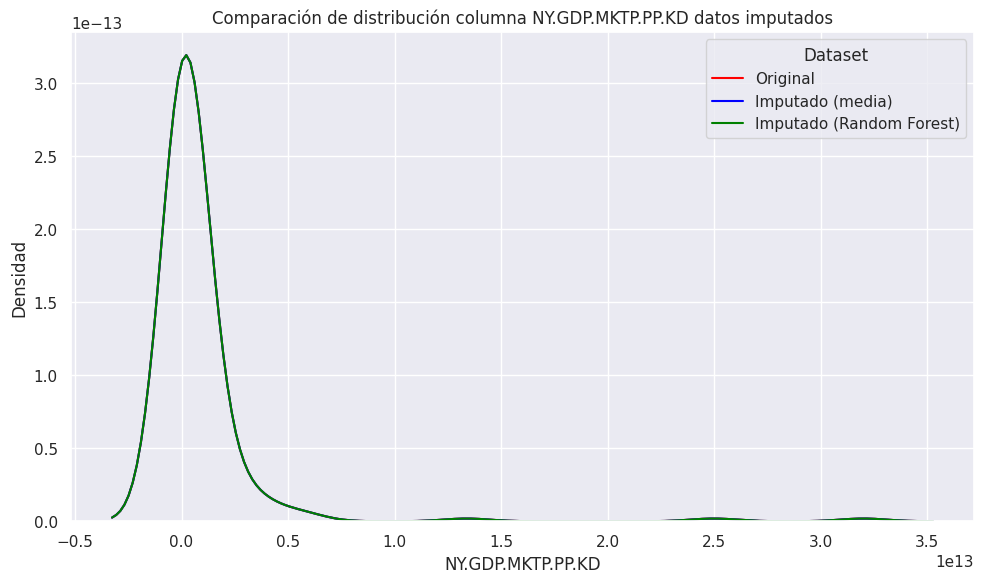

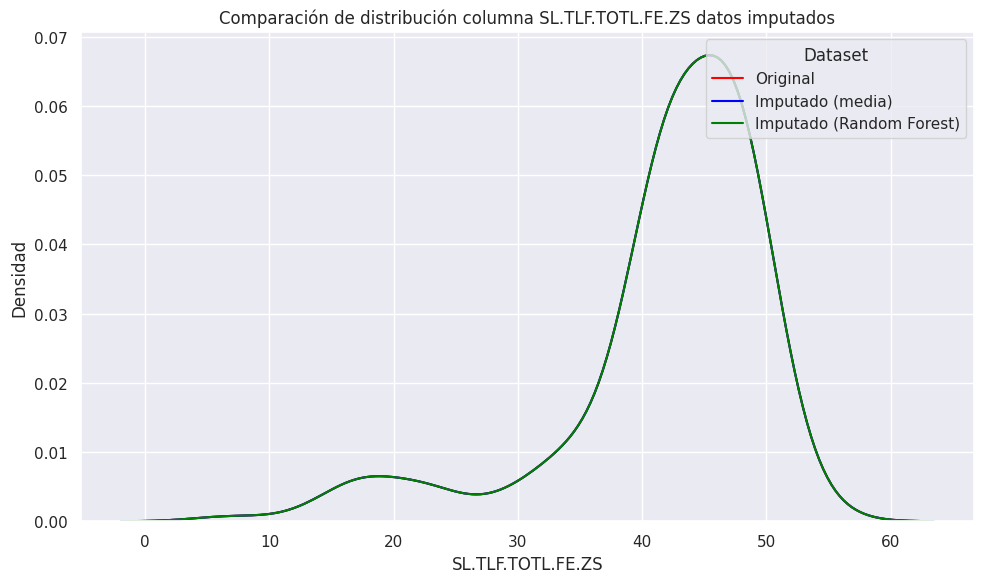

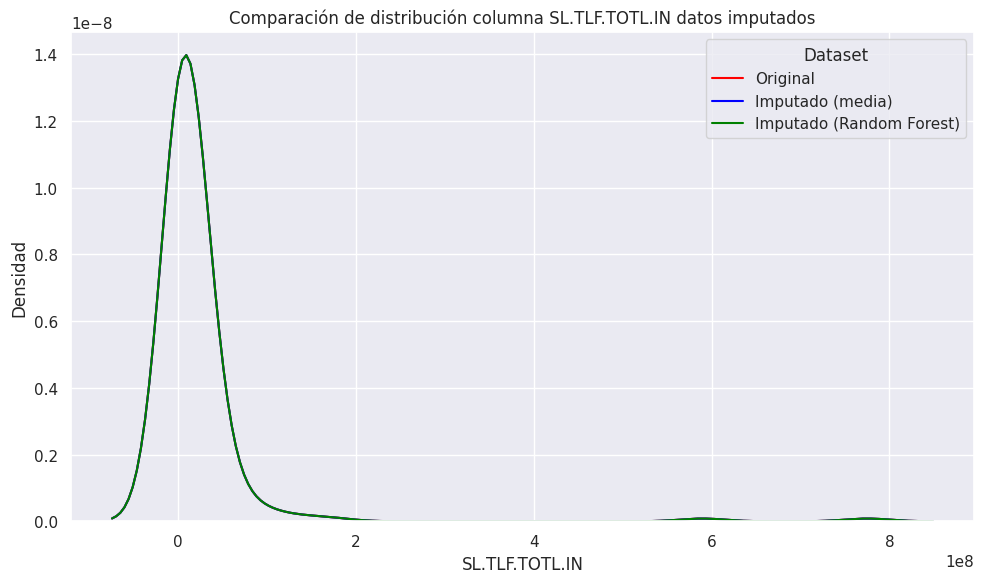

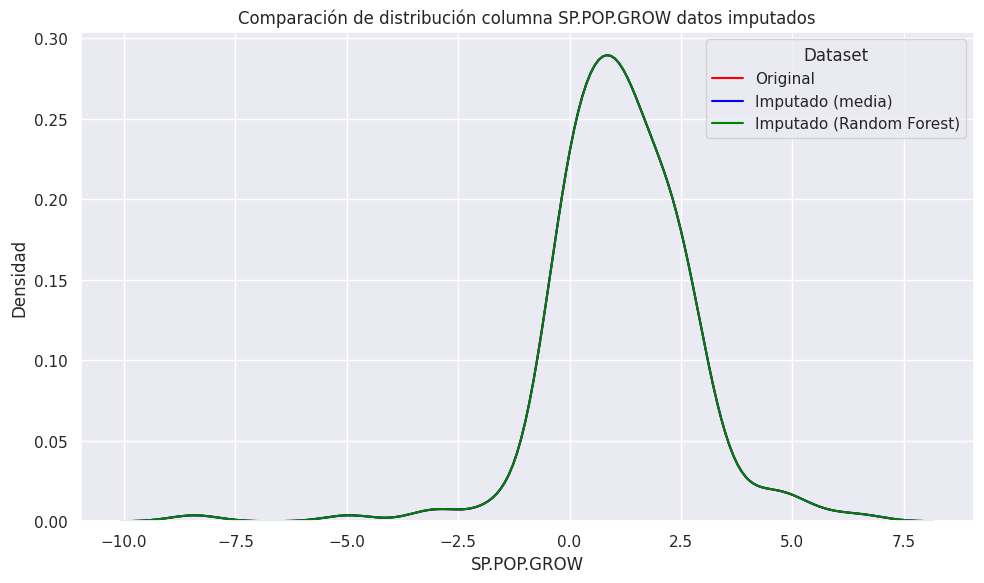

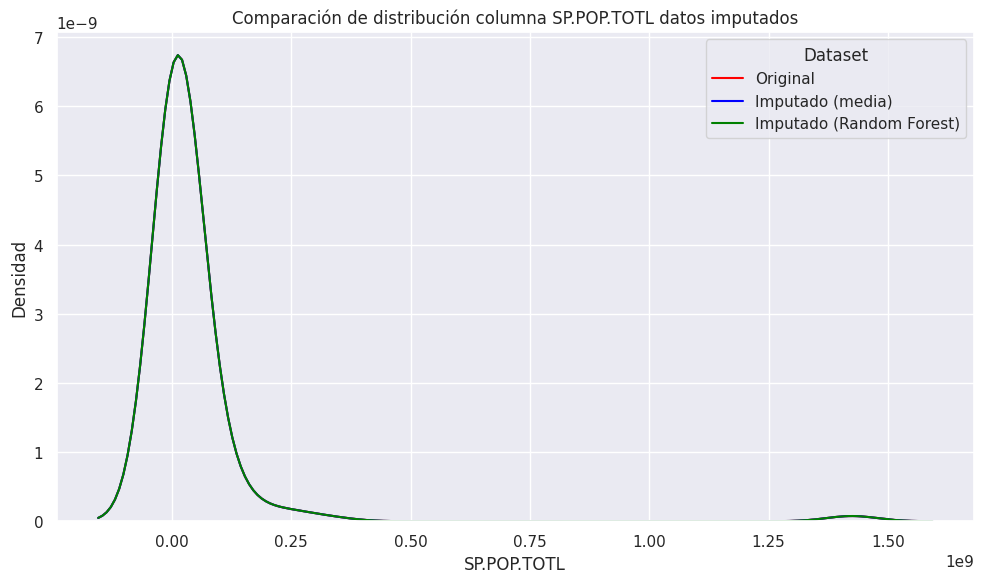

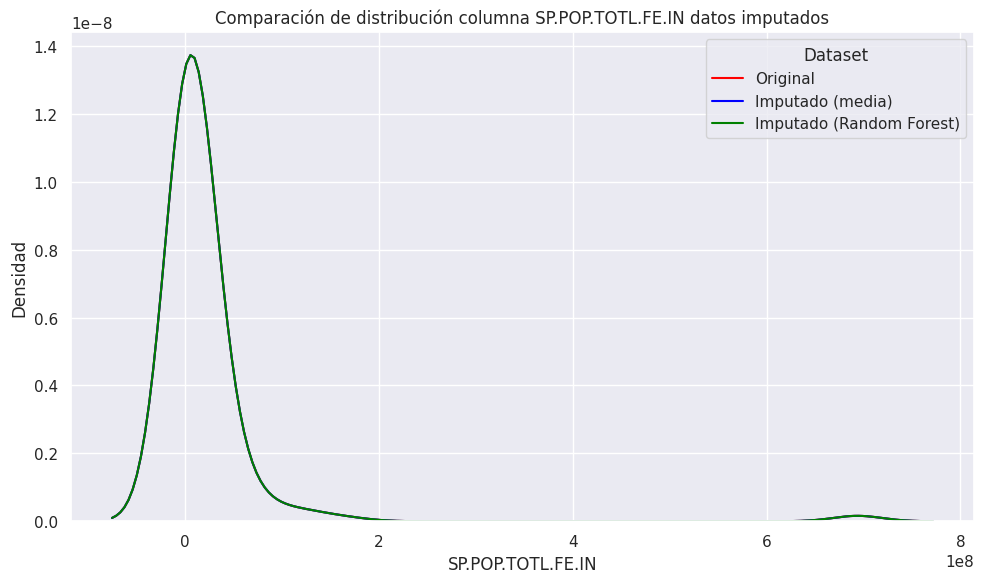

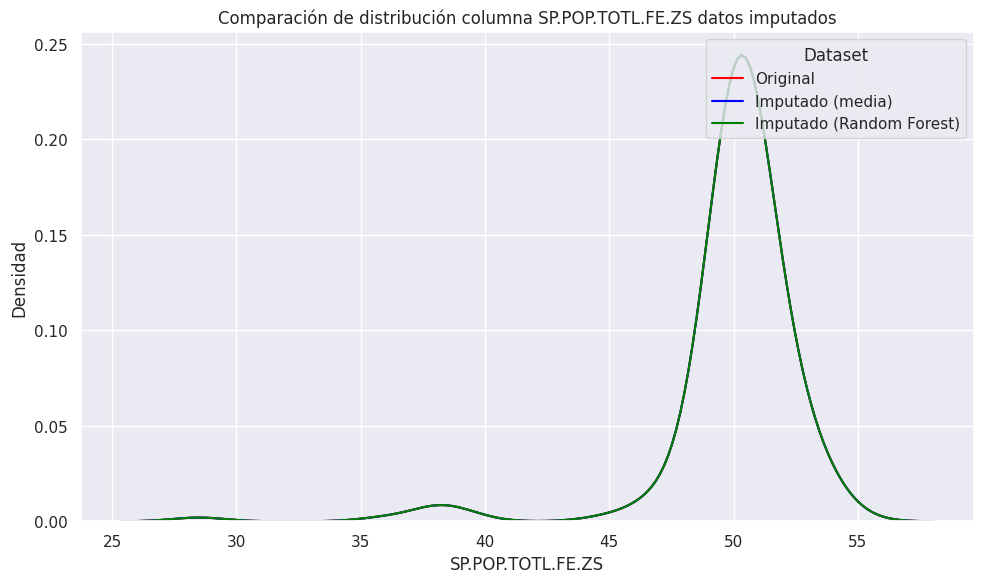

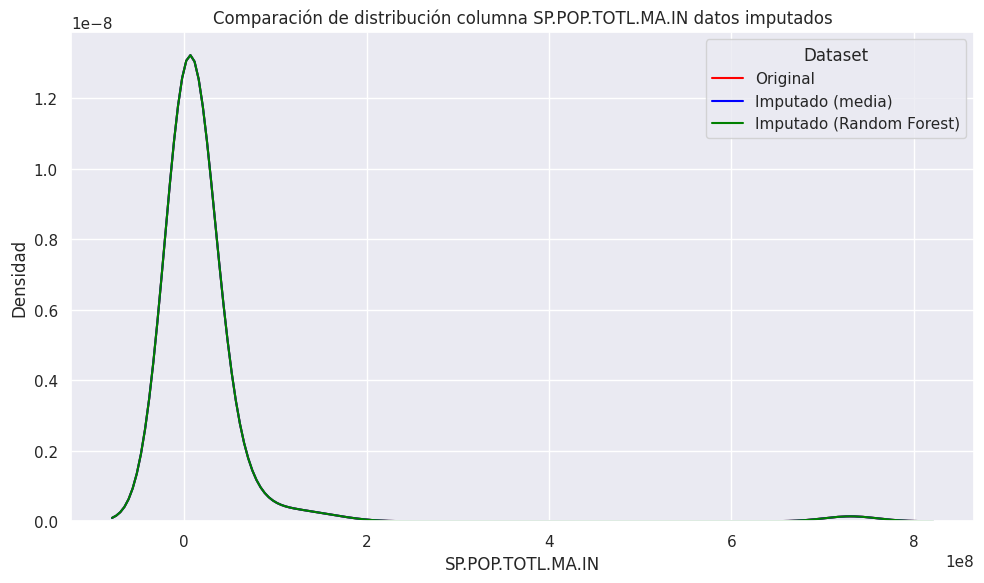

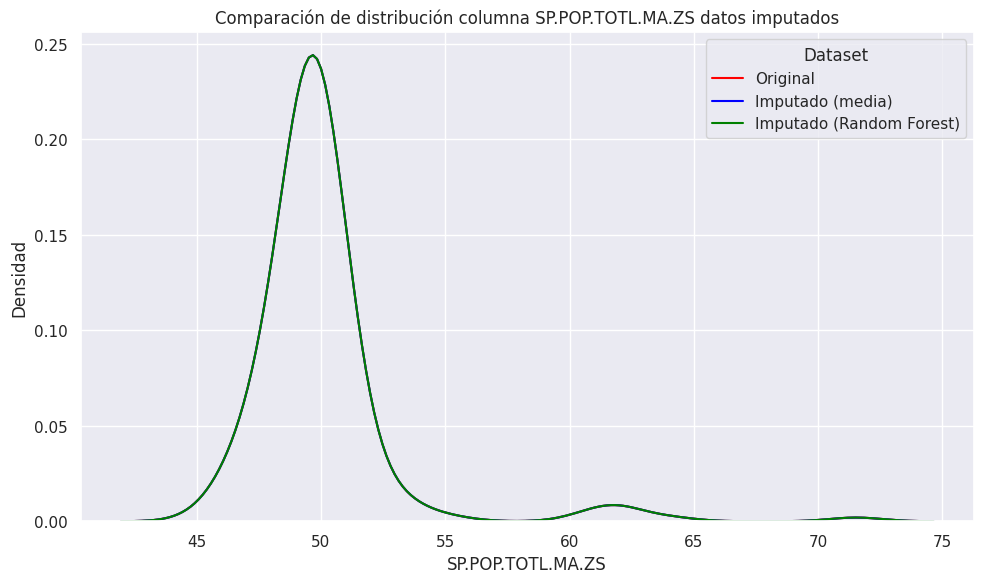

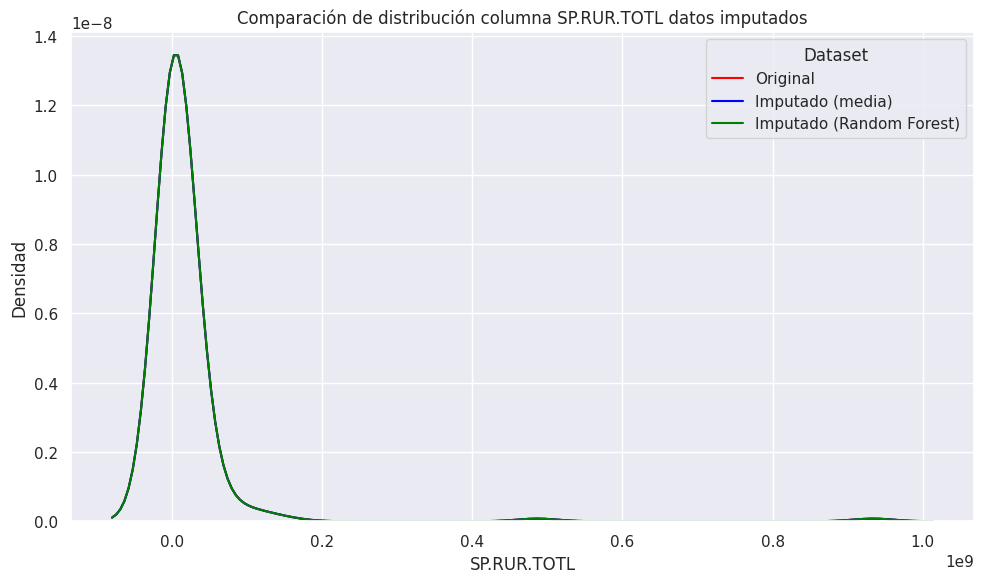

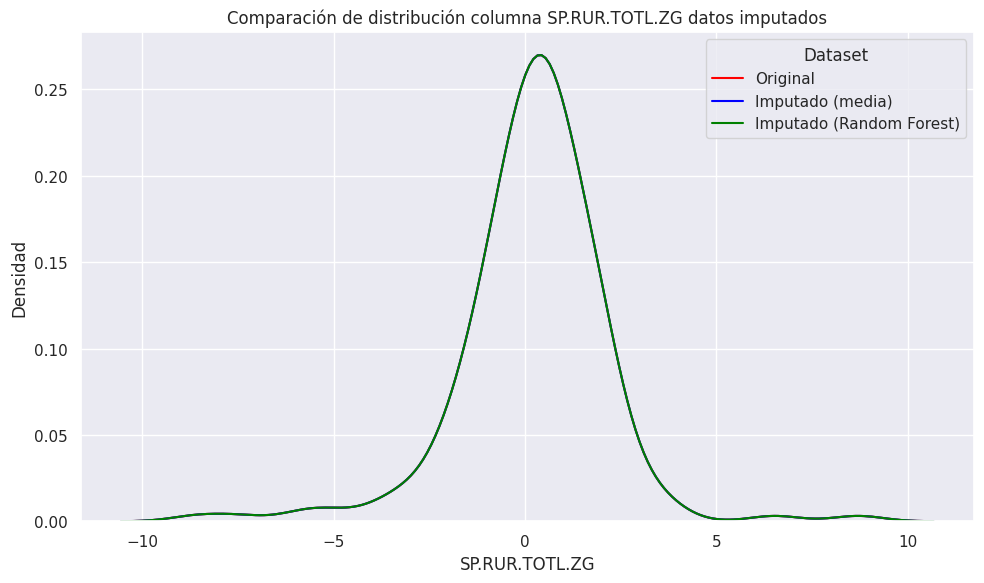

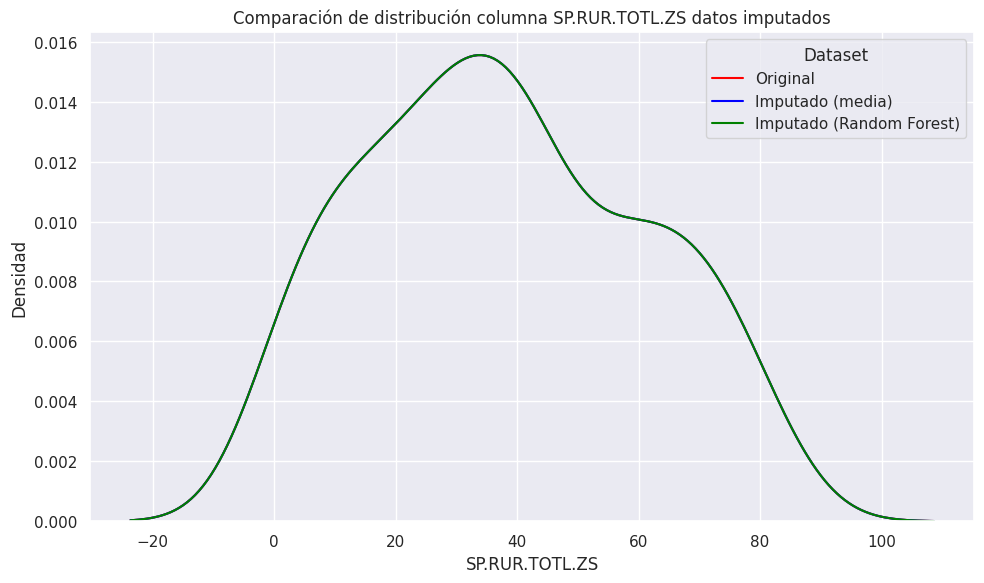

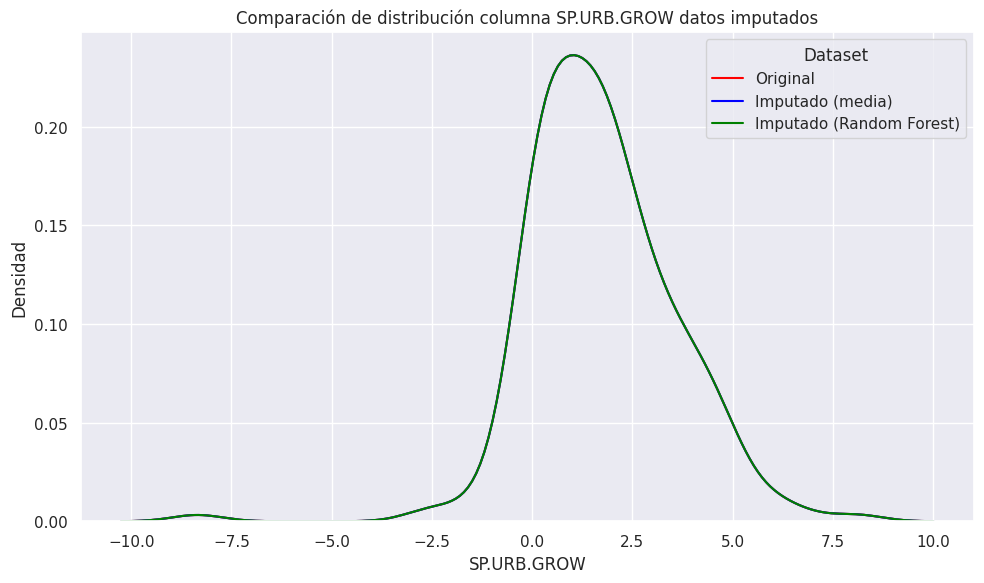

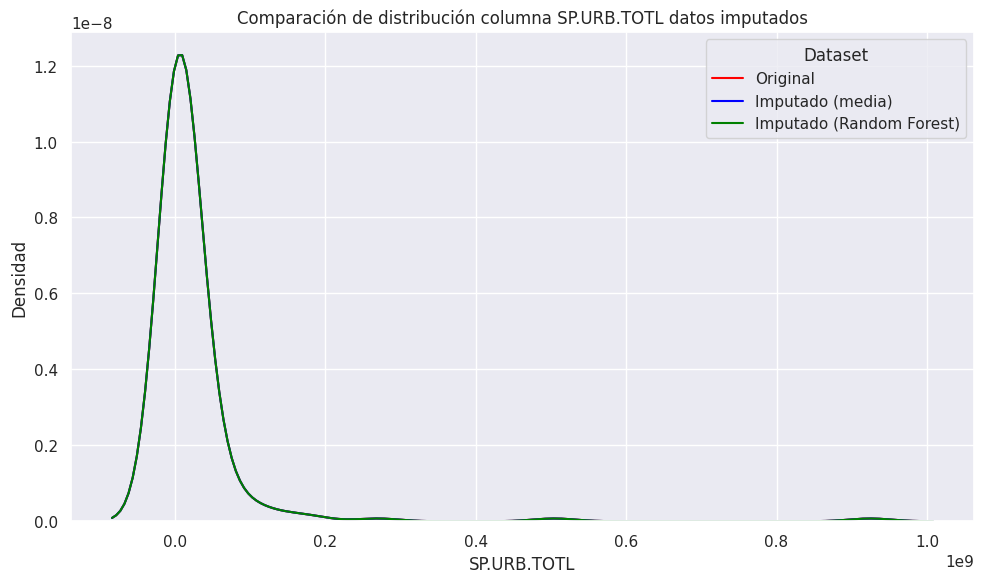

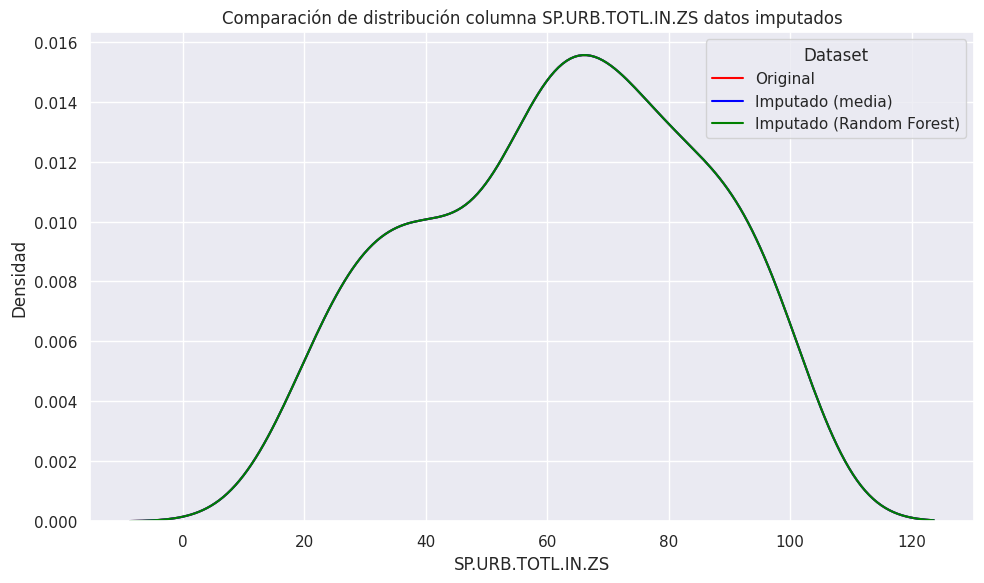

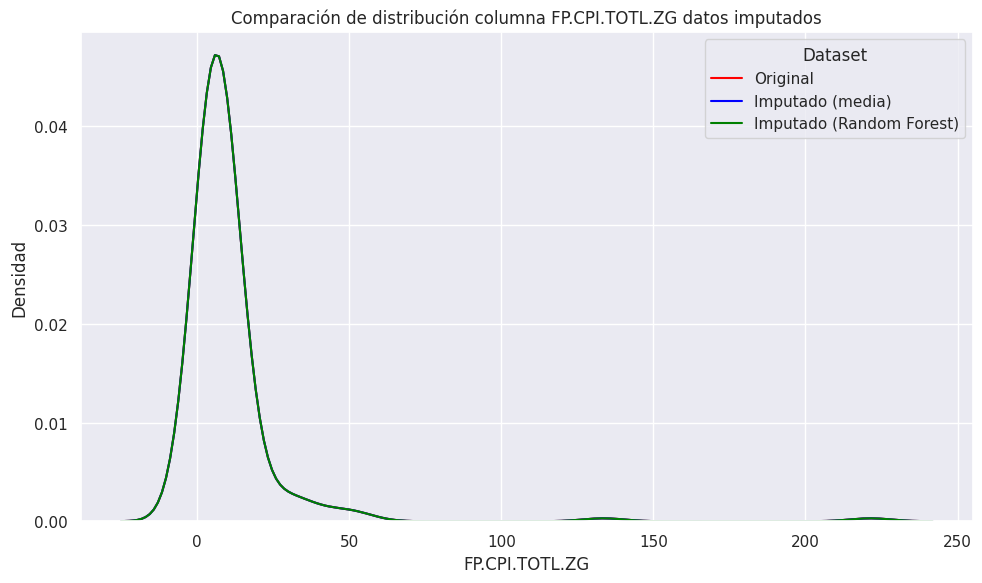

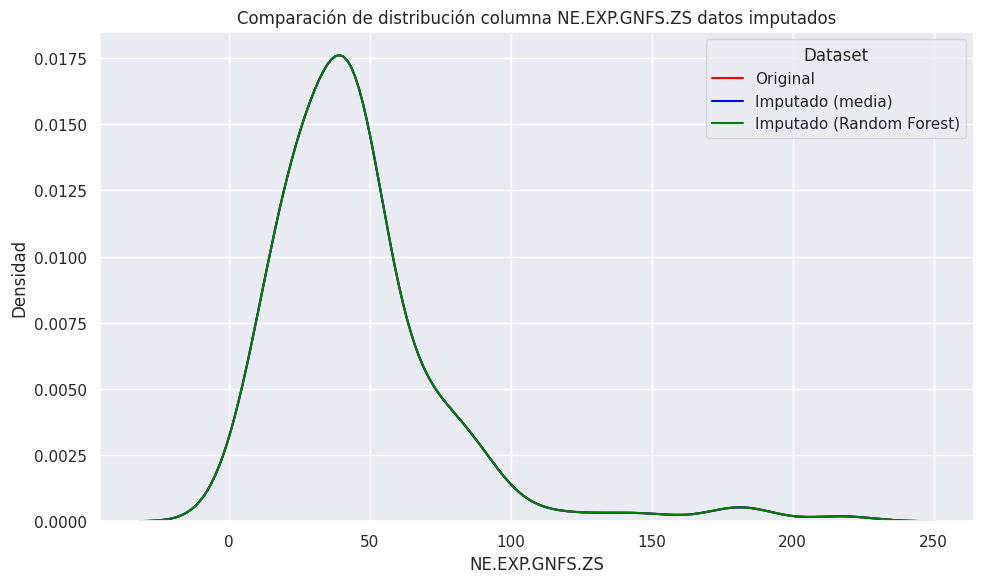

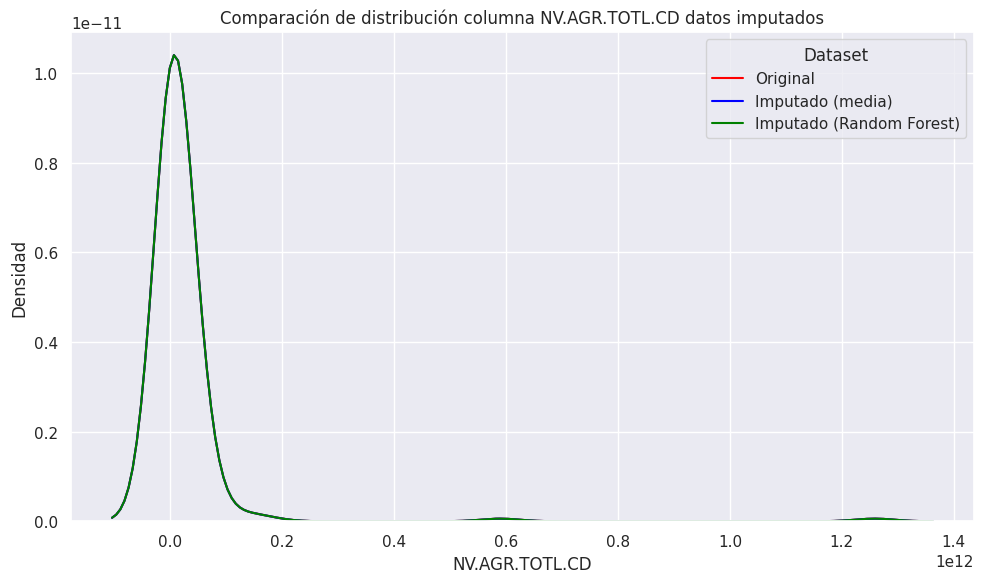

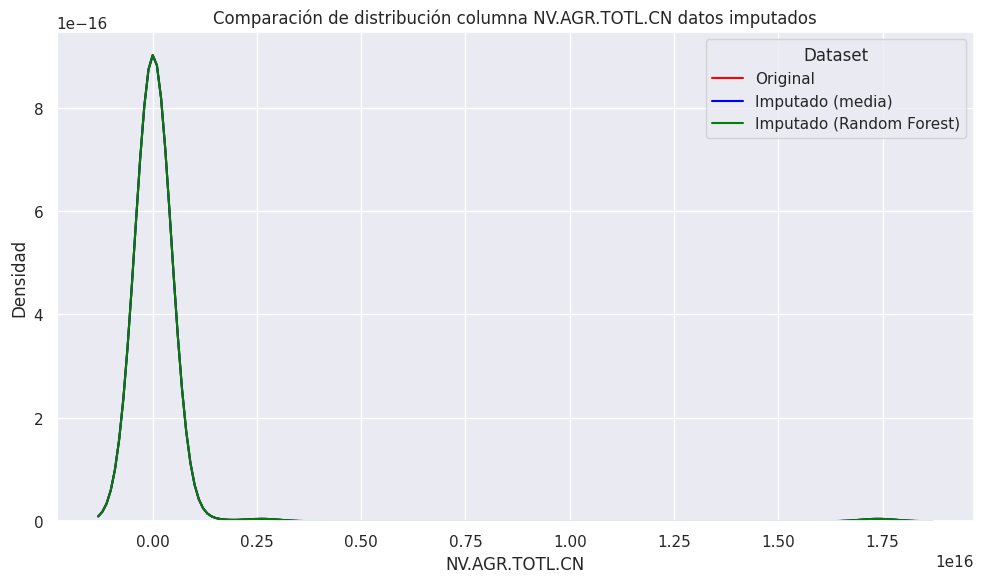

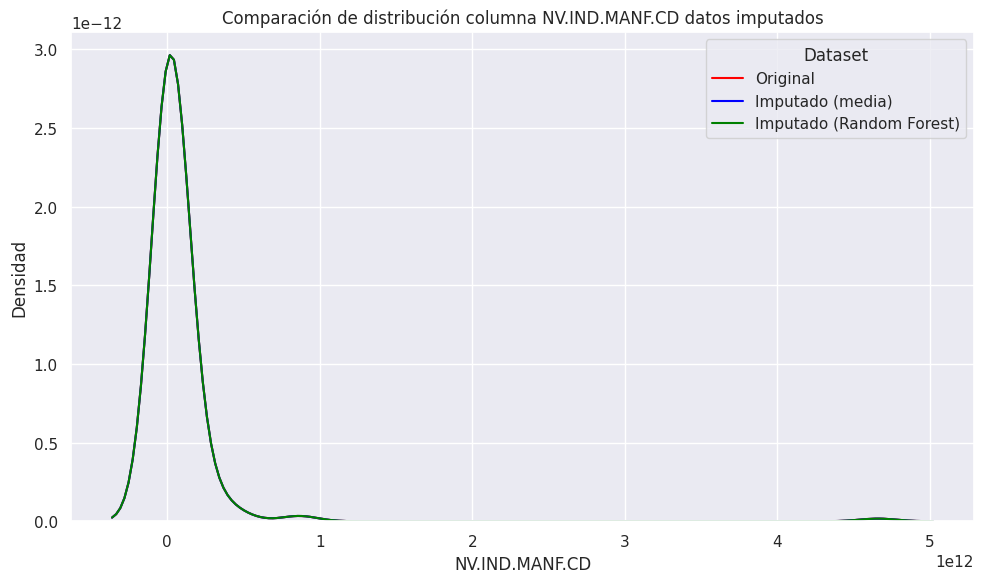

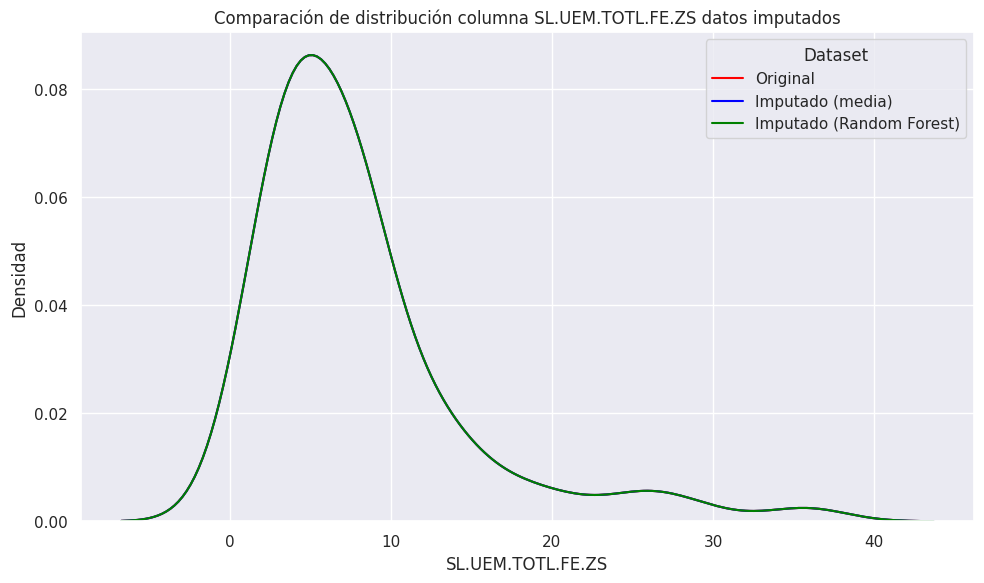

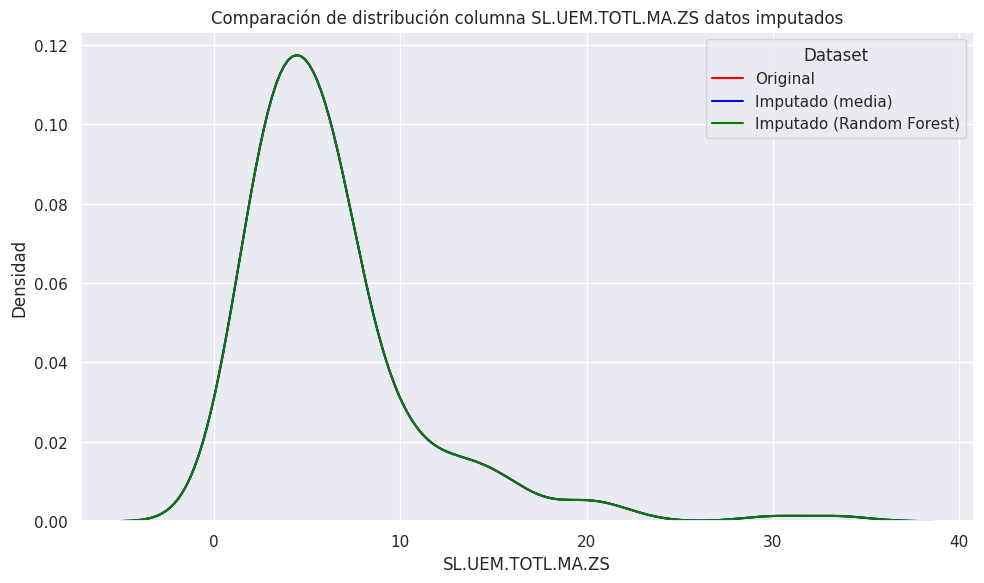

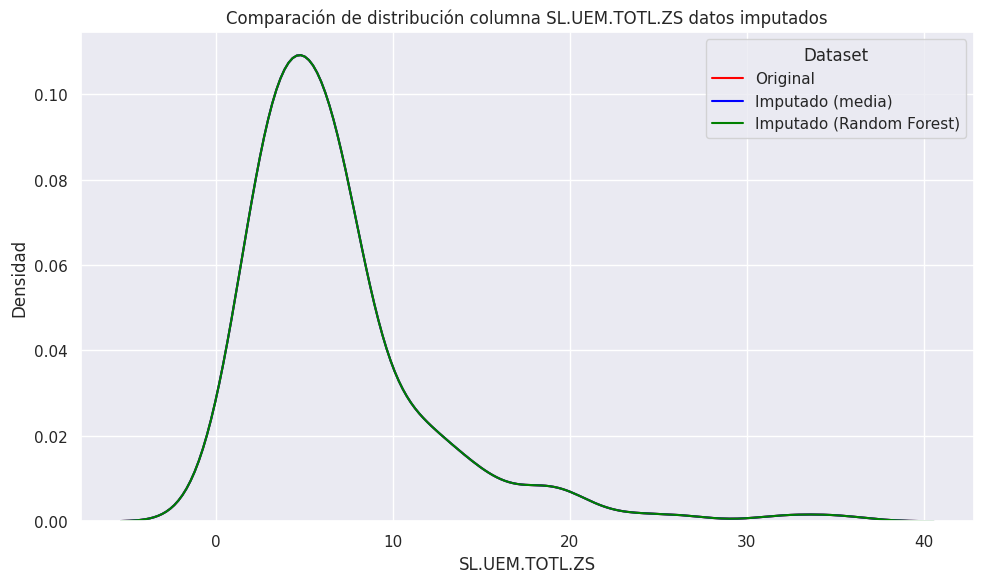

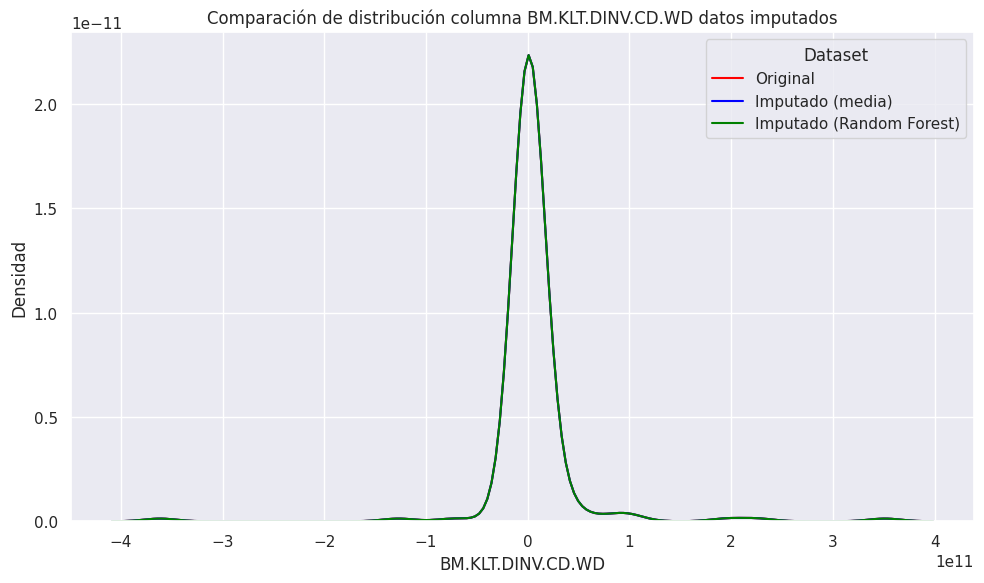

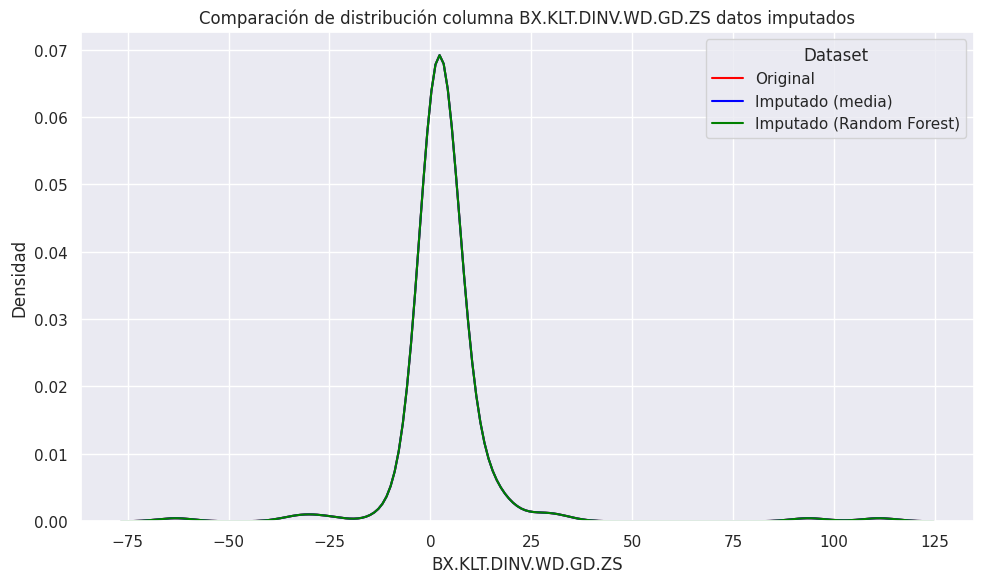

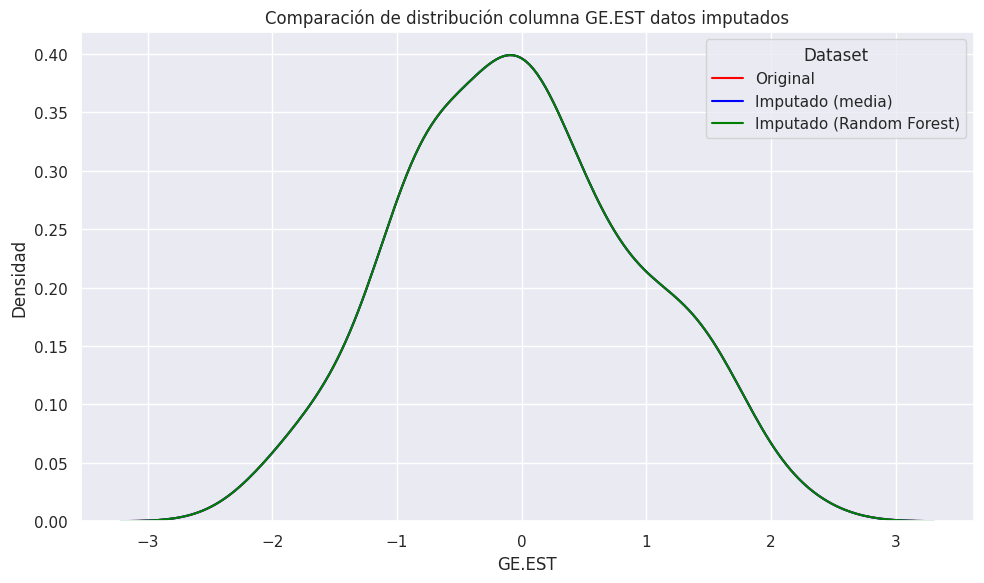

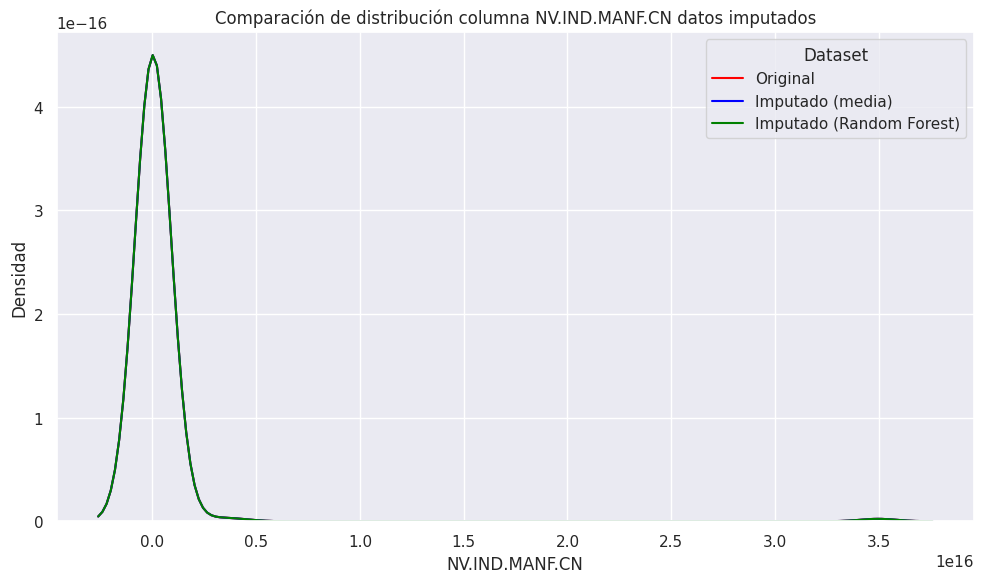

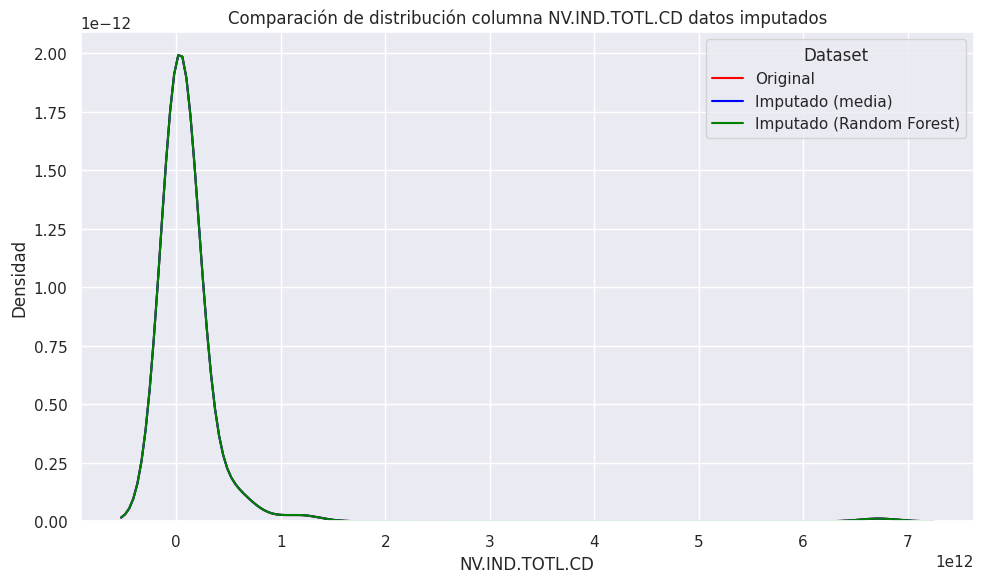

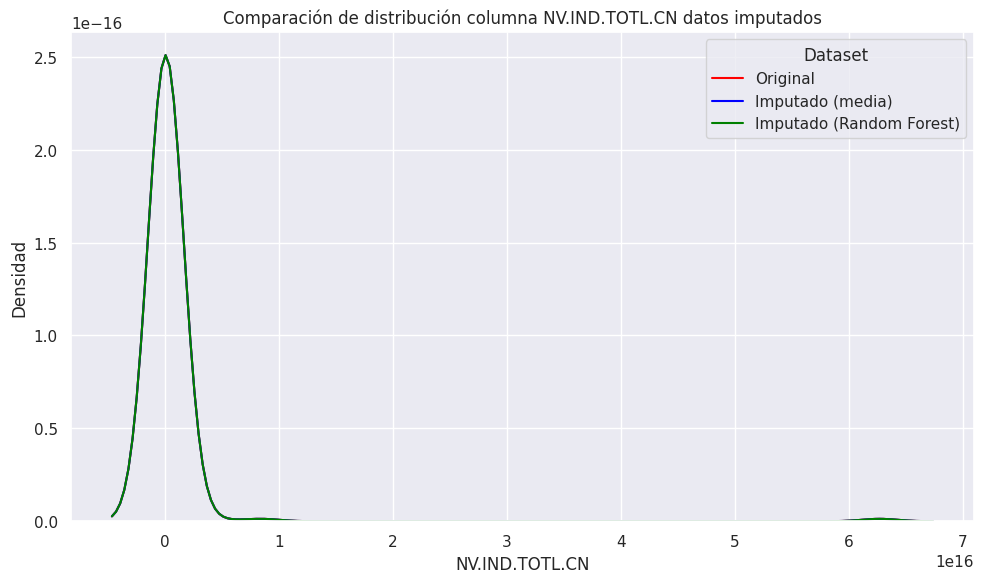

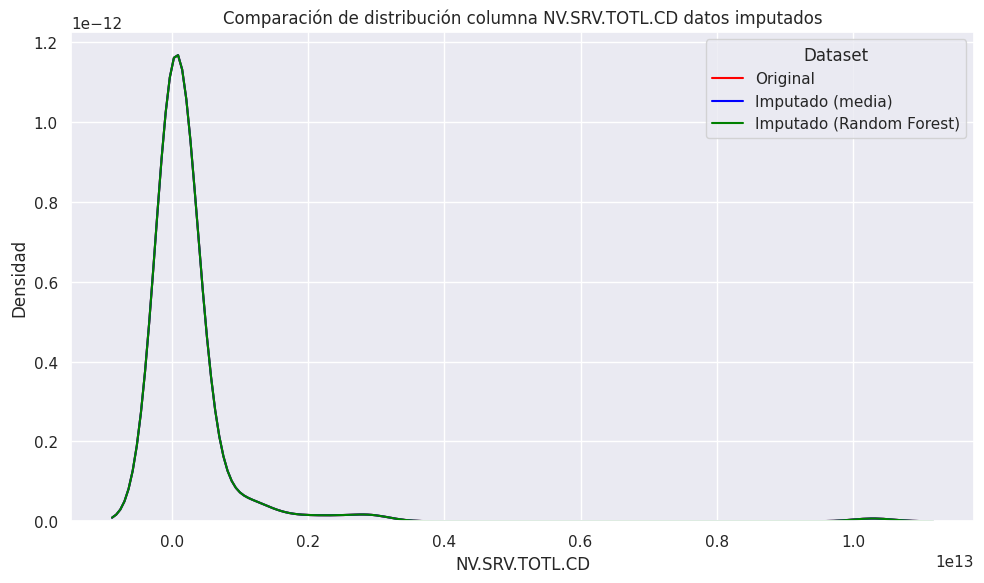

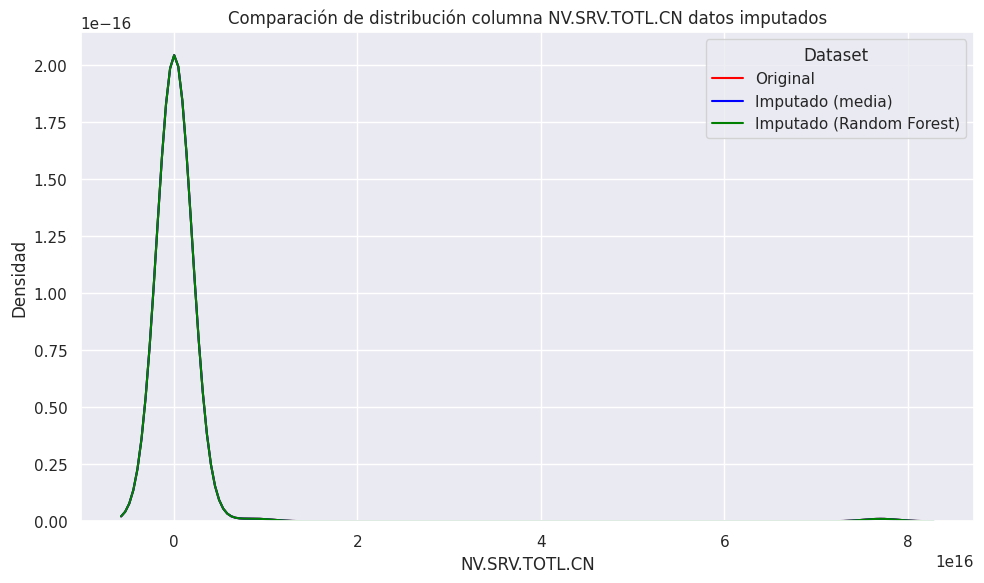

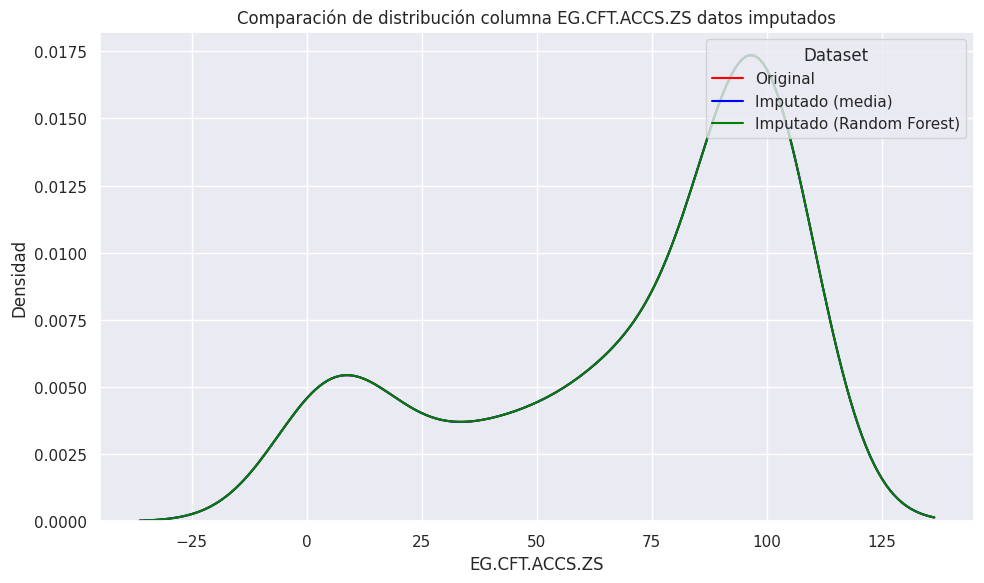

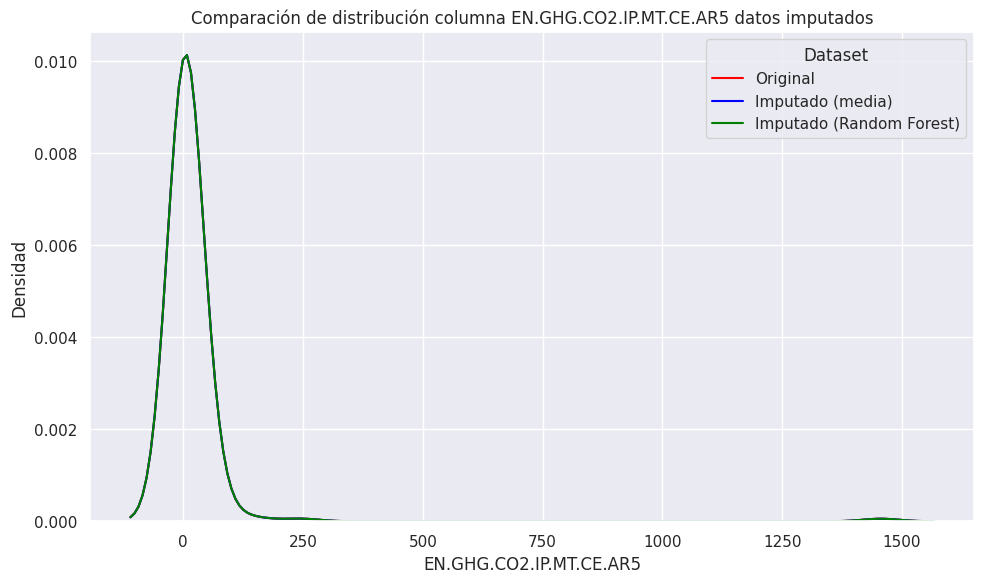

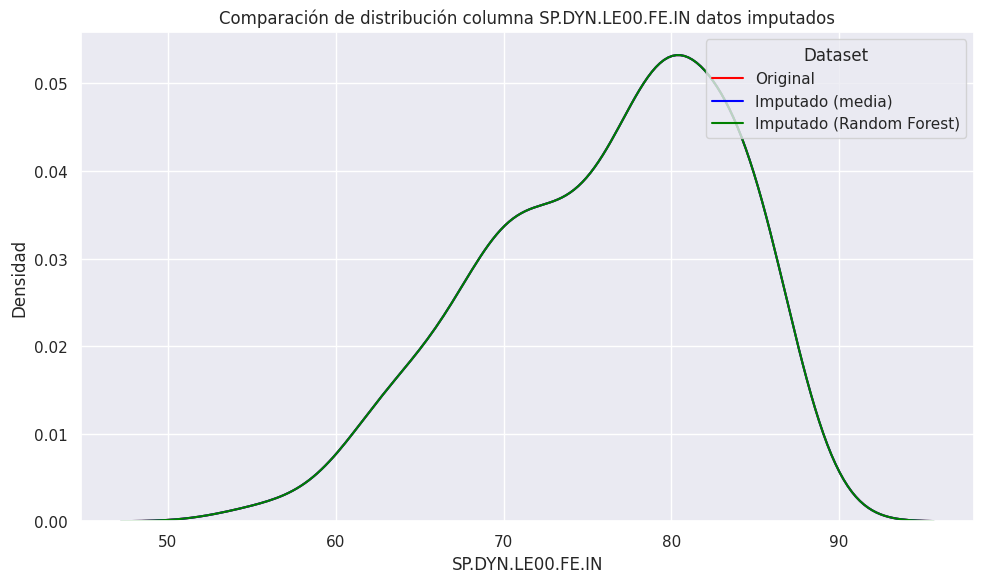

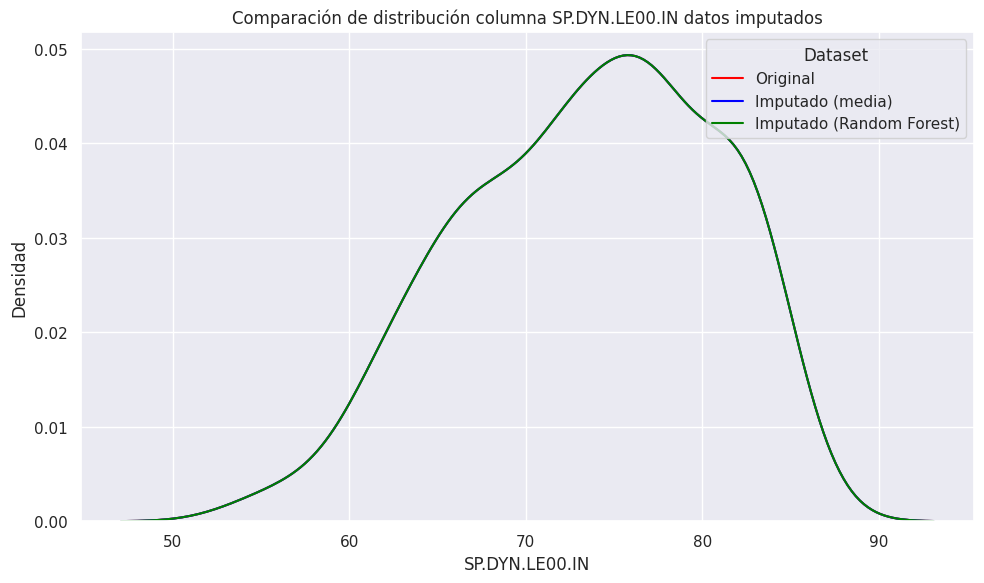

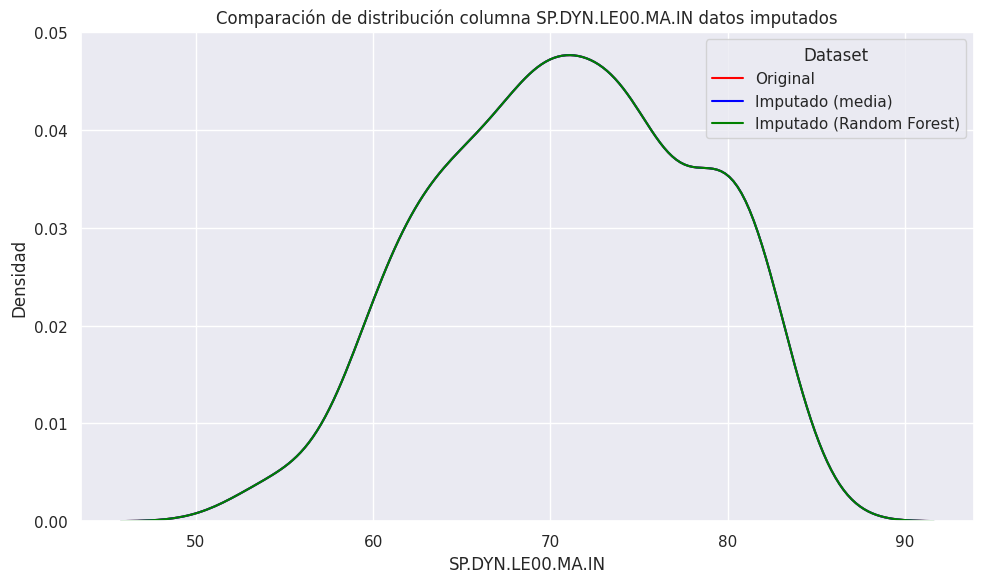

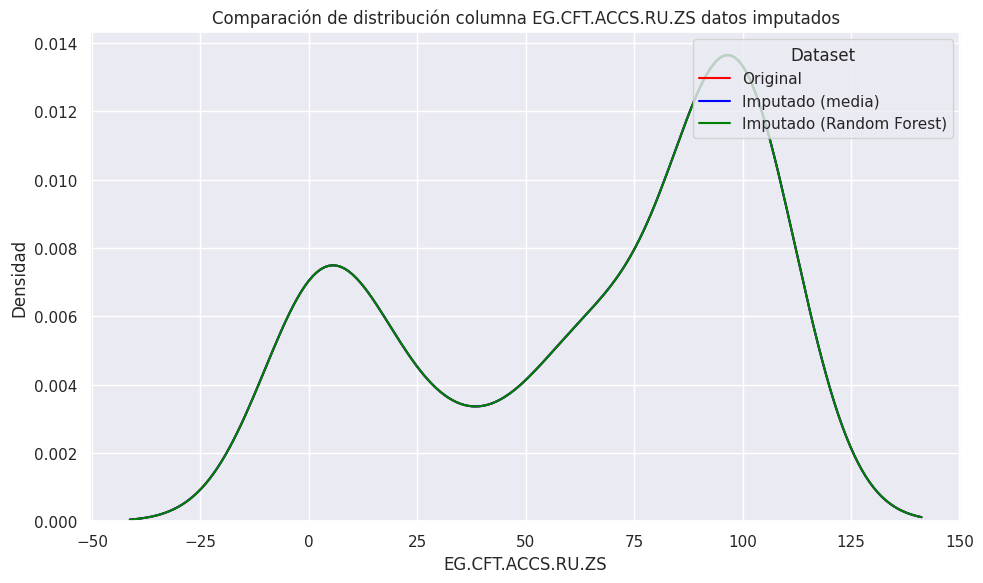

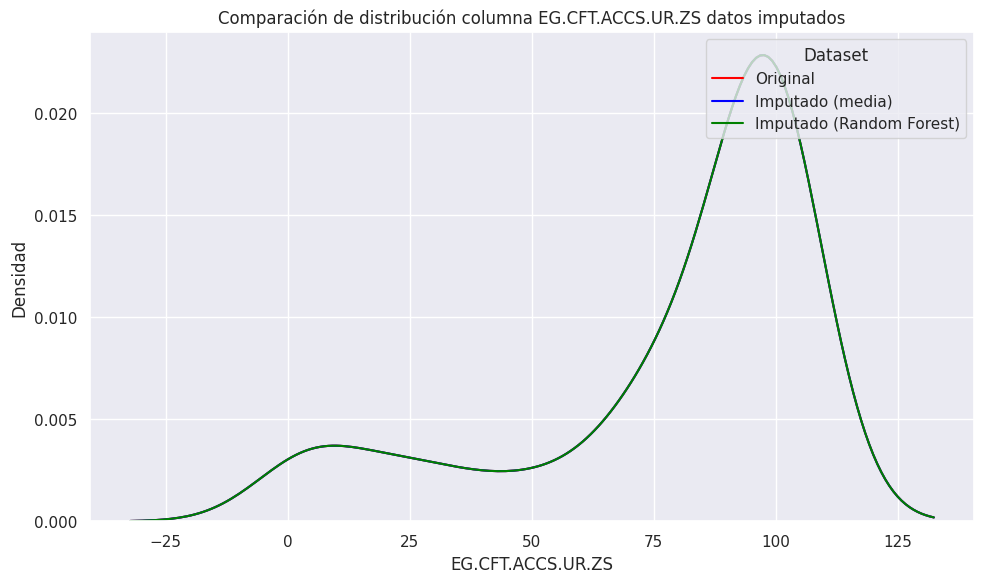

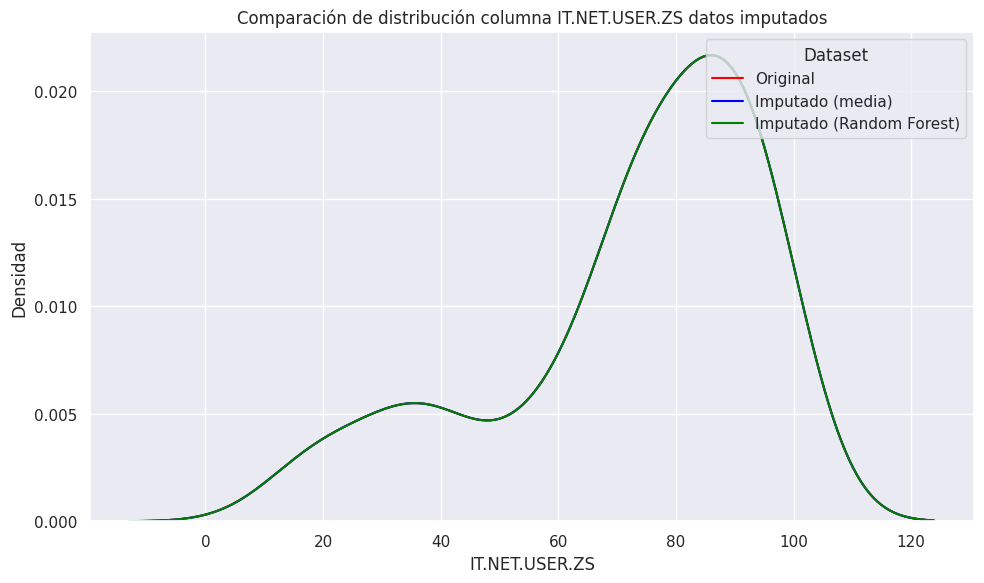

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

columnas = df.select_dtypes(include='number').columns

for col in columnas:
  plt.figure(figsize=(10, 6))
  sns.kdeplot(data=df, x= col, label='Original', color='red')
  sns.kdeplot(data=paises, x=col, label='Imputado (media)', color='blue')
  sns.kdeplot(data=df_rf, x=col, label='Imputado (Random Forest)', color='green')

  plt.legend(title='Dataset', loc='upper right')
  plt.title(f"Comparación de distribución columna {col} datos imputados")
  plt.xlabel(col)
  plt.ylabel("Densidad")
  plt.tight_layout()
  plt.show()

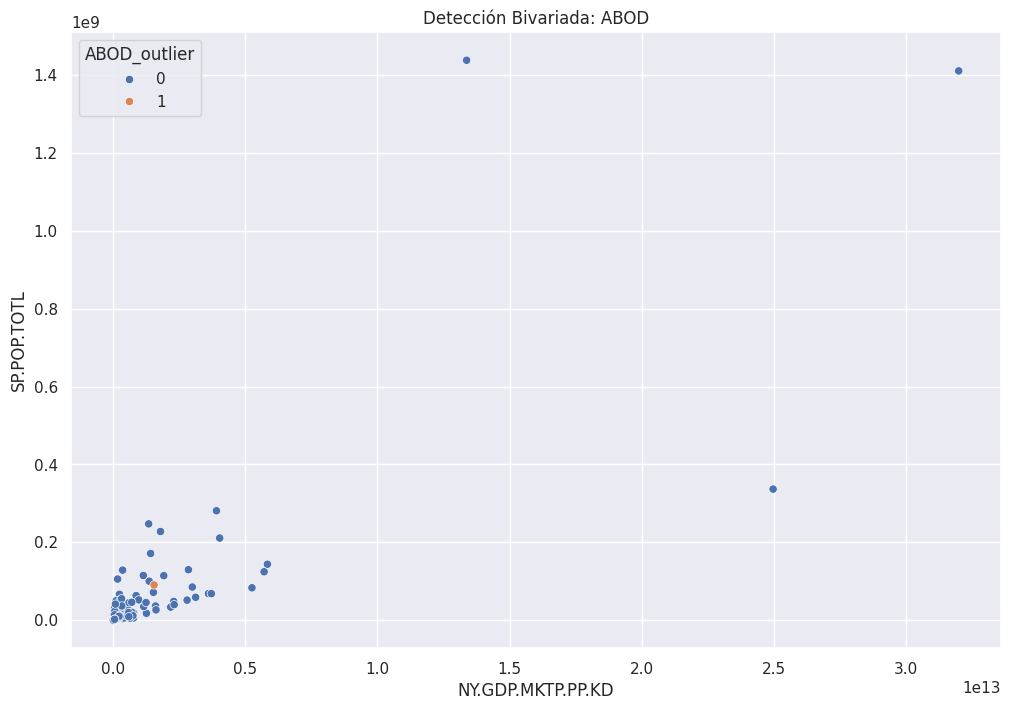

In [56]:
from pyod.models.abod import ABOD

abod_clf = ABOD(contamination=0.01)

df_out = paises_wb.copy()

numeric_cols = df_out.select_dtypes(include=np.number).columns
abod_clf.fit(df_out[numeric_cols])

df_out['ABOD_outlier'] = abod_clf.labels_

sns.set(rc = {'figure.figsize':(12,8)})
sns.scatterplot(data=df_out, x='NY.GDP.MKTP.PP.KD', y='SP.POP.TOTL', hue='ABOD_outlier')
plt.title('Detección Bivariada: ABOD')
plt.show()

El modelo RandomForest es mejor segun lo visto en los graficos

In [57]:
# Escalar datos
scaler = StandardScaler()
data_std = scaler.fit_transform(df_rf)
df_std = pd.DataFrame(data_std, columns=df_rf.columns)

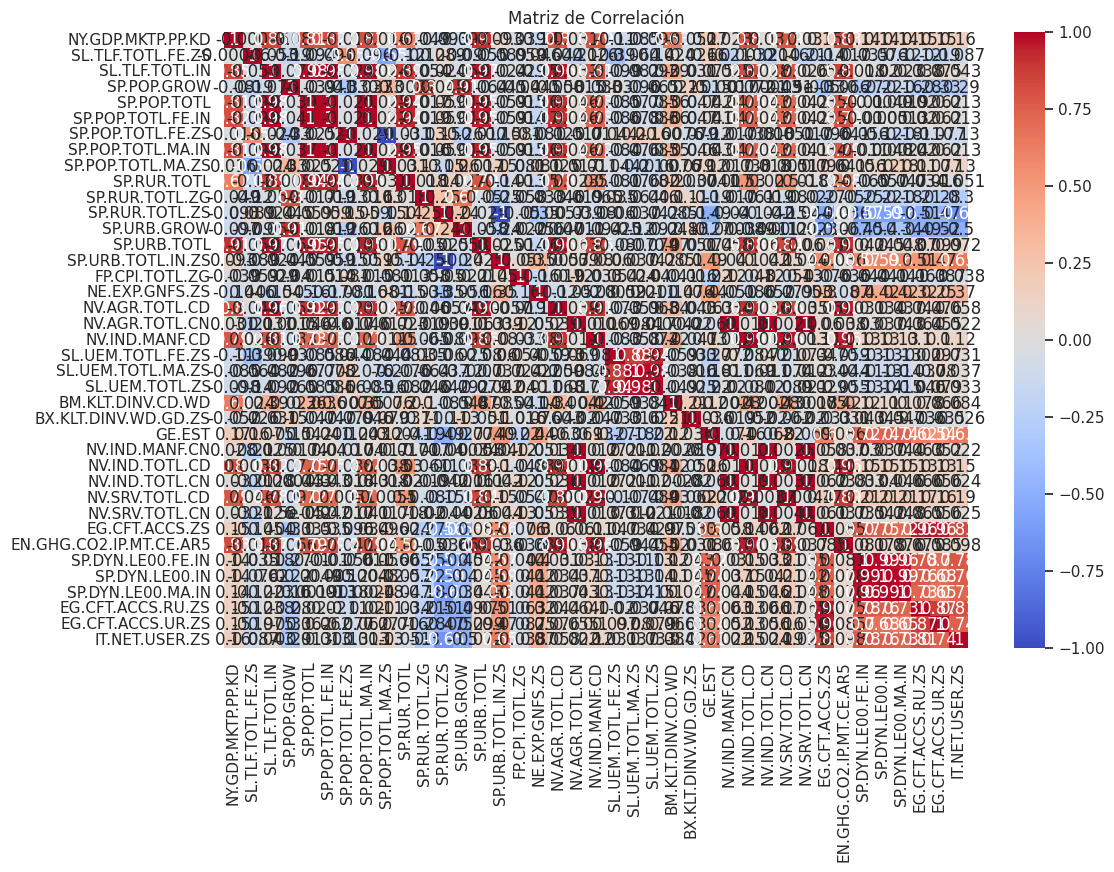

In [58]:
corr = df_std.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Matriz de Correlación")
plt.show()

In [59]:
autovalores, autovectores = np.linalg.eig(corr)
pct_var = autovalores / autovalores.sum()


Varianza explicada

In [60]:
pct_varianza_explicada = autovalores/sum(autovalores)
pct_varianza_explicada

array([ 2.76774214e-01,  2.03701971e-01,  1.06447996e-01,  8.63930298e-02,
        7.22646433e-02,  4.43959574e-02,  3.39303587e-02,  2.89557133e-02,
        2.81663452e-02,  2.59846135e-02,  1.96924655e-02,  1.67264865e-02,
        1.38561311e-02,  1.25924174e-02,  6.74721142e-03,  5.78242040e-03,
        5.04502787e-03,  3.58156981e-03,  2.71389912e-03,  2.26257364e-03,
        1.32720892e-03,  6.89586663e-04,  6.20503014e-04,  4.90305103e-04,
        2.36356355e-04,  1.81105008e-04,  1.59886999e-04,  1.04356065e-04,
        8.63068710e-05,  5.96564171e-05,  1.66922450e-05,  7.26651576e-06,
        1.00398284e-06,  2.53619161e-06,  2.18511201e-06, -2.04534887e-17,
        7.34424999e-19,  9.92888148e-18,  5.93987944e-18])

In [61]:
df_pct_varianza_explicada = pd.DataFrame(sorted(pct_varianza_explicada, reverse = True)[:28], index = ['1','2','3','4','5','6','7','8','9','10','11','12','13','14','15','16','17','18','19','20','21','22','23','24','25','26','27','28']).T

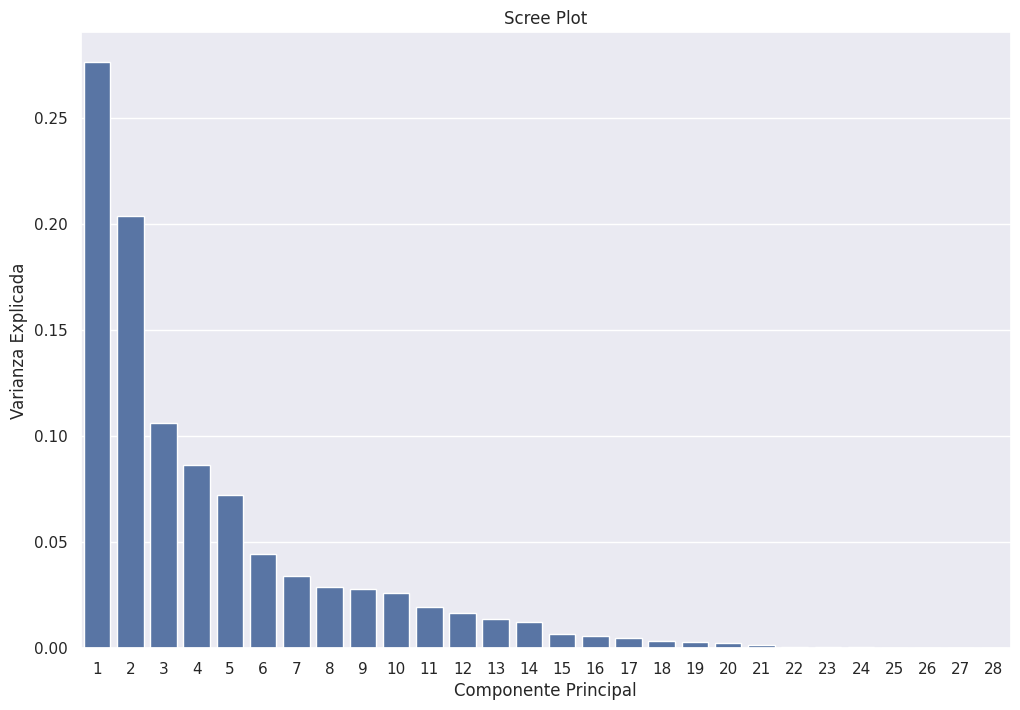

In [62]:
#Graficar varianza explicada
sns.barplot(x=np.arange(1,29), y=pct_var[:28])
plt.xlabel("Componente Principal")
plt.ylabel("Varianza Explicada")
plt.title("Scree Plot")
plt.show()

Determinamos usar 5 componentes, ya que son los que explican mas de 0.05

In [63]:
pca = PCA()
pca.fit(df_std)

pca.explained_variance_ratio_

array([2.76774214e-01, 2.03701971e-01, 1.06447996e-01, 8.63930298e-02,
       7.22646433e-02, 4.43959574e-02, 3.39303587e-02, 2.89557133e-02,
       2.81663452e-02, 2.59846135e-02, 1.96924655e-02, 1.67264865e-02,
       1.38561311e-02, 1.25924174e-02, 6.74721142e-03, 5.78242040e-03,
       5.04502787e-03, 3.58156981e-03, 2.71389912e-03, 2.26257364e-03,
       1.32720892e-03, 6.89586663e-04, 6.20503014e-04, 4.90305103e-04,
       2.36356355e-04, 1.81105008e-04, 1.59886999e-04, 1.04356065e-04,
       8.63068710e-05, 5.96564171e-05, 1.66922450e-05, 7.26651576e-06,
       2.53619161e-06, 2.18511201e-06, 1.00398284e-06, 6.88435312e-31,
       1.99895420e-33, 1.99895420e-33, 1.95809253e-33])

In [64]:
pca_5 = PCA(n_components=5)
data_pca = pca_5.fit_transform(df_std)

df_pca = pd.DataFrame(data_pca, columns=['CP1', 'CP2','CP3', 'CP4','CP5'])
df_pca.head()

,CP1,CP2,CP3,CP4,CP5
0,-1.690604,-3.770015,-0.112548,-1.158990,-0.313207
1,-1.716018,-3.909979,-0.226125,0.860979,-0.281740
2,-0.931523,-0.829346,0.082204,-0.005712,0.644598
3,1.201699,0.387498,0.989437,0.505399,-2.131172
4,-1.328423,-2.808637,-0.150411,0.956621,-0.691203
